# Phase 3: Predictive Early Warning System (EWS)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess
# hmmlearn not needed here, but ensure xgboost is up-to-date
subprocess.run(['pip', 'install', 'xgboost', '-q'], check=True)
print("Packages ready.")

import os
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')
np.random.seed(42)

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (average_precision_score,
                              f1_score, recall_score,
                              precision_score, roc_auc_score)
from sklearn.utils.class_weight import compute_class_weight

import xgboost as xgb
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, Multiply, Lambda,
    Conv1D, GlobalAveragePooling1D, BatchNormalization,
    Activation, Flatten, Permute, RepeatVector
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K

tf.random.set_seed(42)
print(f"TensorFlow version : {tf.__version__}")
print(f"XGBoost    version : {xgb.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")

BASE = ("/content/drive/MyDrive/College Materials/Ajou University/thesis/"
        " Early-Warning System for National Financial Instability")

TVP_PATH    = os.path.join(BASE, "TVP-VAR MODEL/outputs", "tvpvar_connectedness_FILTERED.csv")
HMM_PATH    = os.path.join(BASE, "HMM-TCN", "hmm_regimes.csv")
OUTPUT_DIR  = os.path.join(BASE, "EWS model", "outputs")

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"\nTVP-VAR input : {TVP_PATH}")
print(f"HMM labels    : {HMM_PATH}")
print(f"Output dir    : {OUTPUT_DIR}")
print("Output directory ready.")


Mounted at /content/drive
Packages ready.
TensorFlow version : 2.19.0
XGBoost    version : 3.2.0
GPU available      : False

TVP-VAR input : /content/drive/MyDrive/College Materials/Ajou University/thesis/ Early-Warning System for National Financial Instability/TVP-VAR MODEL/outputs/tvpvar_connectedness_FILTERED.csv
HMM labels    : /content/drive/MyDrive/College Materials/Ajou University/thesis/ Early-Warning System for National Financial Instability/HMM-TCN/hmm_regimes.csv
Output dir    : /content/drive/MyDrive/College Materials/Ajou University/thesis/ Early-Warning System for National Financial Instability/EWS model/outputs
Output directory ready.


## 1. Data Alignment & Dynamic Target Engineering

In [2]:
df_tvp = pd.read_csv(TVP_PATH, parse_dates=['Date'], index_col='Date')
print(f"TVP-VAR   shape : {df_tvp.shape}  |  {df_tvp.index.min().date()} → {df_tvp.index.max().date()}")

df_hmm = pd.read_csv(HMM_PATH, parse_dates=['Date'], index_col='Date')
print(f"HMM labels shape: {df_hmm.shape}  |  {df_hmm.index.min().date()} → {df_hmm.index.max().date()}")

# Inner join ensures only dates present in BOTH files are kept.
# The HMM series is slightly shorter (LOOKBACK=60 rows dropped from the start
# in Phase 2) so the merged frame will follow the HMM date range.
df = df_tvp.join(df_hmm, how='inner')
print(f"\nMerged frame    : {df.shape}  |  {df.index.min().date()} → {df.index.max().date()}")
print(f"Missing values  : {df.isnull().sum().sum()}")
print(f"\nColumns ({len(df.columns)}): {list(df.columns)}")

df.head(3)


TVP-VAR   shape : (5967, 22)  |  2002-01-16 → 2024-12-31
HMM labels shape: (5904, 1)  |  2002-04-15 → 2024-12-31

Merged frame    : (5904, 23)  |  2002-04-15 → 2024-12-31
Missing values  : 0

Columns (23): ['TCI', 'TO_JCI', 'TO_SP500', 'TO_SSE', 'TO_VIX', 'TO_WTI', 'TO_Gold', 'TO_USDIDR', 'FROM_JCI', 'FROM_SP500', 'FROM_SSE', 'FROM_VIX', 'FROM_WTI', 'FROM_Gold', 'FROM_USDIDR', 'NET_JCI', 'NET_SP500', 'NET_SSE', 'NET_VIX', 'NET_WTI', 'NET_Gold', 'NET_USDIDR', 'hmm_state']


,TCI,TO_JCI,TO_SP500,TO_SSE,TO_VIX,TO_WTI,TO_Gold,TO_USDIDR,FROM_JCI,FROM_SP500,...,FROM_Gold,FROM_USDIDR,NET_JCI,NET_SP500,NET_SSE,NET_VIX,NET_WTI,NET_Gold,NET_USDIDR,hmm_state
Date,,,,,,,,,,,,,,,,,,,,,
2002-04-15,54.538013,5.790538,7.591301,8.660459,6.399368,12.270671,6.864862,6.960815,7.282251,8.914881,...,7.886888,9.254511,-1.491713,-1.323581,0.937992,-0.412147,5.605172,-1.022026,-2.293697,3
2002-04-16,55.389423,5.834335,6.953698,8.973051,6.522921,10.499333,7.570658,9.035427,8.235156,8.455286,...,7.747515,8.728905,-2.400821,-1.501588,1.086968,-0.571770,3.257547,-0.176857,0.306522,3
2002-04-17,56.091585,6.589524,7.541360,10.066086,5.489116,12.717326,5.887245,7.800927,7.526059,8.413506,...,8.299725,9.240005,-0.936535,-0.872146,2.670265,-1.920837,4.910811,-2.412480,-1.439078,3


In [3]:
# The HMM assigns arbitrary integer IDs (0–K-1) to each state.
# We identify the "Crisis State" as the one with the highest mean TCI,
# consistent with Diebold & Yilmaz (2014): systemic stress → elevated connectedness.
#
# METHODOLOGICAL NOTE (Q1 rigour):
# This GLOBAL identification is for display/reference only.
# The CV loop in Step 3.2 recomputes CRISIS_STATE using ONLY the training fold
# to prevent look-ahead bias from leaking future TCI distributions into the
# target variable definition.

tci_by_state = df.groupby('hmm_state')['TCI'].mean().sort_values(ascending=False)
CRISIS_STATE = int(tci_by_state.idxmax())   # state integer with highest mean TCI

print("Mean TCI per HMM state (sorted high → low):")
print(tci_by_state.to_frame(name='Mean TCI').to_string())
print(f"\nGlobal Crisis State (reference): State {CRISIS_STATE}  (mean TCI = {tci_by_state[CRISIS_STATE]:.3f})")
print(f"   Days in Crisis State : {(df['hmm_state'] == CRISIS_STATE).sum()}  "
      f"({(df['hmm_state'] == CRISIS_STATE).mean()*100:.1f}% of total)")
print("\n[!] CV loop will recompute CRISIS_STATE on each training fold independently.")


Mean TCI per HMM state (sorted high → low):
            Mean TCI
hmm_state           
1          52.071117
3          48.525325
0          48.279732
2          47.253482
4          45.837365

Global Crisis State (reference): State 1  (mean TCI = 52.071)
   Days in Crisis State : 1205  (20.4% of total)

[!] CV loop will recompute CRISIS_STATE on each training fold independently.


In [ ]:
# For each day t, Target_Nd = 1 if the Crisis State appears in [t+1 … t+N].
# Implementation:  rolling max over the next N rows of the binary crisis_flag series.
# .shift(-1)  : look one step ahead (exclude day t itself)
# .rolling(N) : any crisis day in the next N days?
# .max()      : 1 if at least one day in the window is a crisis day

HORIZON_40 = 40   # ~2 trading months
HORIZON_60 = 60   # ~3 trading months

crisis_flag = (df['hmm_state'] == CRISIS_STATE).astype(int)

# Forward rolling max (look ahead N days starting from t+1)
# Equivalent to: Target(t) = max(crisis_flag[t+1 ... t+N])
df['Target_40d'] = (
    crisis_flag
    .shift(-1)                  # align so index t looks forward
    .rolling(HORIZON_40, min_periods=HORIZON_40)
    .max()
    .shift(-(HORIZON_40 - 1))  # pull the window result back to day t
)

df['Target_60d'] = (
    crisis_flag
    .shift(-1)
    .rolling(HORIZON_60, min_periods=HORIZON_60)
    .max()
    .shift(-(HORIZON_60 - 1))
)

# ── Bussiere & Fratzscher (2006): exclude days ALREADY in crisis (post-crisis bias) ──
# Days where S_t = S_crisis are set to NA → removed from the sample entirely.
# Rationale: a model trained on in-crisis days learns to CONFIRM crisis, not PREDICT it.
# The EWS should only learn from pre-crisis (lead-up) vs. tranquil (no crisis ahead) days.
in_crisis_mask = (df['hmm_state'] == CRISIS_STATE)
df.loc[in_crisis_mask, 'Target_40d'] = np.nan
df.loc[in_crisis_mask, 'Target_60d'] = np.nan
n_excluded = in_crisis_mask.sum()
print(f"Days excluded (S_t = Crisis, post-crisis bias removal): {n_excluded}  "
      f"({n_excluded / (len(df)) * 100:.1f}% of raw sample)")

# Drop tail NaNs (forward window beyond data end) AND in-crisis NaNs
df.dropna(subset=['Target_40d', 'Target_60d'], inplace=True)
df['Target_40d'] = df['Target_40d'].astype(int)
df['Target_60d'] = df['Target_60d'].astype(int)

print(f"\nDataset shape after exclusion : {df.shape}")
print(f"Date range : {df.index.min().date()}  →  {df.index.max().date()}")
print()

print(f"{'':12}  {'OLD (no exclusion)':>35}   {'NEW (Bussiere excl.)':>35}")
old_40_pos, old_40_neg   = 2303, 3541   # stored from previous run
old_60_pos, old_60_neg   = 2741, 3103
new_40_pos = df['Target_40d'].sum();  new_40_neg = len(df) - new_40_pos
new_60_pos = df['Target_60d'].sum();  new_60_neg = len(df) - new_60_pos

print(f"{'Target_40d':12}  Crisis={old_40_pos} ({old_40_pos/(old_40_pos+old_40_neg)*100:.1f}%)  "
      f"Normal={old_40_neg} ({old_40_neg/(old_40_pos+old_40_neg)*100:.1f}%)   |   "
      f"Crisis={new_40_pos} ({new_40_pos/len(df)*100:.1f}%)  "
      f"Normal={new_40_neg} ({new_40_neg/len(df)*100:.1f}%)")
print(f"{'Target_60d':12}  Crisis={old_60_pos} ({old_60_pos/(old_60_pos+old_60_neg)*100:.1f}%)  "
      f"Normal={old_60_neg} ({old_60_neg/(old_60_pos+old_60_neg)*100:.1f}%)   |   "
      f"Crisis={new_60_pos} ({new_60_pos/len(df)*100:.1f}%)  "
      f"Normal={new_60_neg} ({new_60_neg/len(df)*100:.1f}%)")
print()

for target in ['Target_40d', 'Target_60d']:
    pos = df[target].sum()
    neg = len(df) - pos
    print(f"{target}  |  Crisis=1: {pos:>5} days ({pos/len(df)*100:.1f}%)   "
          f"Normal=0: {neg:>5} days ({neg/len(df)*100:.1f}%)   "
          f"Imbalance ratio: 1 : {neg/max(pos,1):.1f}")

Days excluded (S_t = Crisis, post-crisis bias removal): 1205  (20.4% of raw sample)

Dataset shape after exclusion : (4639, 25)
Date range : 2002-04-15  →  2024-08-14

── Comparison: OLD vs NEW target distribution ──────────────────────────────
                               OLD (no exclusion)                  NEW (Bussiere excl.)
Target_40d    Crisis=2303 (39.4%)  Normal=3541 (60.6%)   |   Crisis=1123 (24.2%)  Normal=3516 (75.8%)
Target_60d    Crisis=2741 (46.9%)  Normal=3103 (53.1%)   |   Crisis=1555 (33.5%)  Normal=3084 (66.5%)

Target_40d  |  Crisis=1:  1123 days (24.2%)   Normal=0:  3516 days (75.8%)   Imbalance ratio: 1 : 3.1
Target_60d  |  Crisis=1:  1555 days (33.5%)   Normal=0:  3084 days (66.5%)   Imbalance ratio: 1 : 2.0


## 2. Walk-Forward Expanding-Window Validation Setup

Feature columns (22): ['TCI', 'TO_JCI', 'TO_SP500', 'TO_SSE', 'TO_VIX', 'TO_WTI', 'TO_Gold', 'TO_USDIDR', 'FROM_JCI', 'FROM_SP500', 'FROM_SSE', 'FROM_VIX', 'FROM_WTI', 'FROM_Gold', 'FROM_USDIDR', 'NET_JCI', 'NET_SP500', 'NET_SSE', 'NET_VIX', 'NET_WTI', 'NET_Gold', 'NET_USDIDR']

Sample count    : 4639
Reference class balance   : 40d -> 24.2% crisis  |  60d -> 33.5% crisis


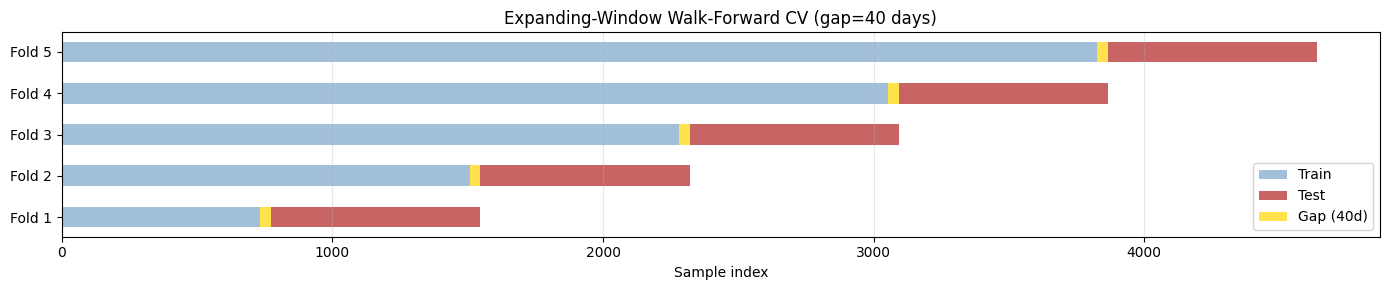

Fold sizes:
  Fold 1: train=734  DL-train=587  gap=40  test=773  [DL SKIP]
  Fold 2: train=1,507  DL-train=1,205  gap=40  test=773  [DL OK]
  Fold 3: train=2,280  DL-train=1,824  gap=40  test=773  [DL OK]
  Fold 4: train=3,053  DL-train=2,442  gap=40  test=773  [DL OK]
  Fold 5: train=3,826  DL-train=3,060  gap=40  test=773  [DL OK]
Fold visualisation saved.


In [5]:

FEATURE_COLS = [c for c in df.columns if c not in ('hmm_state', 'Target_40d', 'Target_60d')]
print(f"Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")

X_raw    = df[FEATURE_COLS].values          # shape: (T, 22) — unscaled raw features
hmm_raw  = df['hmm_state'].values           # shape: (T,)
y_40_ref = df['Target_40d'].values.astype(int)  # global reference (class balance display only)
y_60_ref = df['Target_60d'].values.astype(int)

T_total = len(X_raw)
print(f"\nSample count    : {T_total}")
print(f"Reference class balance   : 40d -> {y_40_ref.mean()*100:.1f}% crisis  |  60d -> {y_60_ref.mean()*100:.1f}% crisis")

LOOKBACK     = 90     # TCN / ALSTM sequence length (~4.5 trading months); wider window captures pre-crisis buildup
N_SPLITS     = 5      # number of walk-forward folds
BATCH_SIZE   = 64
DL_EPOCHS    = 200    # max; EarlyStopping kicks in earlier
ES_PATIENCE  = 15
VAL_FRAC     = 0.20   # last 20% of each training fold used as internal DL validation
MIN_DL_TRAIN = 700    # Fold 1 DL training set = 925*0.8 = 740 > 700; all 5 folds run

# gap=HORIZON_40 inserts a 40-day buffer between each train end and test start,
# preventing boundary contamination from the forward-rolling-max target construction.
tscv = TimeSeriesSplit(n_splits=N_SPLITS, gap=HORIZON_40)

fig, ax = plt.subplots(figsize=(14, 3))
for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_raw)):
    ax.barh(fold, len(tr_idx), left=0,
            height=0.5, color='steelblue', alpha=0.5, label='Train' if fold==0 else '')
    ax.barh(fold, len(te_idx), left=len(tr_idx) + HORIZON_40,
            height=0.5, color='firebrick', alpha=0.7, label='Test' if fold==0 else '')
    ax.barh(fold, HORIZON_40,  left=len(tr_idx),
            height=0.5, color='gold',     alpha=0.7, label=f'Gap ({HORIZON_40}d)' if fold==0 else '')

ax.set_yticks(range(N_SPLITS))
ax.set_yticklabels([f'Fold {f+1}' for f in range(N_SPLITS)])
ax.set_xlabel('Sample index')
ax.set_title(f'Expanding-Window Walk-Forward CV (gap={HORIZON_40} days)', fontsize=12)
ax.legend(loc='lower right')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ch2_wfcv_structure.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Fold sizes:")
for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_raw)):
    dl_n = int(len(tr_idx) * (1 - VAL_FRAC))
    print(f"  Fold {fold+1}: train={len(tr_idx):,}  DL-train={dl_n:,}  gap={HORIZON_40}  test={len(te_idx):,}  "
          f"{'[DL OK]' if dl_n >= MIN_DL_TRAIN else '[DL SKIP]'}")
print("Fold visualisation saved.")


## 3. Model Definitions & Helper Functions

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# A. Sliding-Window Sequence Builder
def make_sequences(X: np.ndarray, y: np.ndarray, lookback: int):
    n_samples = len(X) - lookback + 1
    X_seq = np.stack([X[i : i + lookback] for i in range(n_samples)])
    y_seq = y[lookback - 1:]
    return X_seq.astype(np.float32), y_seq.astype(np.float32)


# B. XGBoost / Logit / RF — 4-statistic window summary features (4*F features)
def build_xgb_features(X_3d: np.ndarray) -> np.ndarray:
    """
    (N, LOOKBACK, F) -> (N, 4*F): [mean, std, last, delta] per TVP-VAR series.
    Captures level, volatility, current state, and directional momentum over
    the lookback window without requiring sequential model architecture.
    """
    mean  = X_3d.mean(axis=1)
    std   = X_3d.std(axis=1)
    last  = X_3d[:, -1, :]
    delta = X_3d[:, -1, :] - X_3d[:, 0, :]
    return np.concatenate([mean, std, last, delta], axis=1)


# C. Optimal Decision Threshold (F1-maximising on validation set)
def find_optimal_threshold(y_val: np.ndarray, prob_val: np.ndarray) -> float:
    """
    Sweep 99 candidate thresholds in [0.01, 0.99] and return the one that
    maximises F1 on the validation set. Falls back to 0.5 if single-class.
    No floor is applied here — caller decides minimum acceptable threshold.
    """
    if len(np.unique(y_val)) < 2:
        return 0.5
    best_t, best_f1 = 0.5, 0.0
    for t in np.linspace(0.01, 0.99, 99):
        f1 = f1_score(y_val, (prob_val >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return float(best_t)


# D. Platt Scaling — recalibrate DL probabilities post-training
def platt_scale(prob_val: np.ndarray, y_val: np.ndarray,
                prob_te: np.ndarray) -> np.ndarray:
    """
    Fit a 1-parameter logistic regression on (prob_val, y_val) and apply to
    prob_te. Corrects systematic probability miscalibration from class_weight
    training. Falls back to identity if val set is single-class.
    """
    if len(np.unique(y_val)) < 2:
        return prob_te
    cal = LogisticRegression(C=1.0, solver='lbfgs', max_iter=200)
    cal.fit(prob_val.reshape(-1, 1), y_val.astype(int))
    return cal.predict_proba(prob_te.reshape(-1, 1))[:, 1].astype(np.float32)


# E. Logistic Regression (Classical EWS Benchmark — Kaminsky & Reinhart 1999)
#    solver='saga' supports L1/L2 and scales to larger feature sets
#    C tuned per fold via inner TimeSeriesSplit GridSearchCV
def build_logit(C: float = 0.1, class_weight: str = 'balanced') -> LogisticRegression:
    return LogisticRegression(
        C=C, class_weight=class_weight,
        solver='saga', max_iter=1000, random_state=42,
    )


# F. Random Forest (Bagging Benchmark — Breiman 2001)
#    balanced_subsample recomputes class weights per tree for robust imbalance handling
#    n_estimators & max_depth tuned per fold via inner TimeSeriesSplit GridSearchCV
def build_rf(n_estimators: int = 200, max_depth: int = 6) -> RandomForestClassifier:
    """
    Balanced-subsample class weights recompute per tree, providing robust
    imbalance handling without inflating minority predictions globally.
    min_samples_leaf=5 prevents memorising tiny leaf splits on small folds.
    max_features='sqrt' is the standard Breiman recommendation for classification.
    """
    return RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        max_features='sqrt',
        class_weight='balanced_subsample',
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
    )


# G. ALSTM — Attention-augmented LSTM (Bahdanau soft attention)
#      lstm_units=24       (small capacity to prevent in-sample memorisation on small folds)
#      dropout=0.40        (strong stochastic regularisation)
#      recurrent_dropout=0.15
#      L2=5e-4             (weight decay on LSTM kernel + Dense)
def build_alstm(n_features: int, lookback: int,
                lstm_units: int = 24, dropout: float = 0.40) -> tf.keras.Model:
    """
    Bahdanau self-attention over LSTM hidden states.
    Compact architecture (24 units, dropout=0.40) calibrated for walk-forward
    fold sizes (~740 samples min). L2 regularisation on LSTM kernel/recurrent
    weights and Dense layer prevents memorisation on small folds.
    Compiled with PR-AUC metric (curve='PR') so EarlyStopping monitors the
    primary evaluation metric directly — more informative than ROC-AUC for
    imbalanced targets.
    """
    _l2 = tf.keras.regularizers.l2(5e-4)
    inp   = Input(shape=(lookback, n_features), name='input')
    h_seq = LSTM(lstm_units, return_sequences=True,
                 dropout=dropout, recurrent_dropout=0.15,
                 kernel_regularizer=_l2, recurrent_regularizer=_l2,
                 name='lstm')(inp)
    score   = Dense(1, use_bias=False, name='attn_score')(h_seq)
    alpha   = Activation('softmax', name='attn_weights')(score)
    context = Lambda(
        lambda args: tf.reduce_sum(args[0] * args[1], axis=1), name='context'
    )([h_seq, alpha])
    x   = Dropout(dropout, name='drop1')(context)
    x   = Dense(24, activation='relu', kernel_regularizer=_l2, name='fc1')(x)
    x   = Dropout(dropout, name='drop2')(x)
    out = Dense(1, activation='sigmoid', name='output')(x)
    model = Model(inputs=inp, outputs=out, name='ALSTM')
    model.compile(
        optimizer=Adam(5e-4),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(curve='PR', name='pr_auc')],
    )
    return model


# H. Causal TCN — Dilated Causal 1D CNN
#    Tweaks vs. baseline:
#      dilations [1,2,4,8] → [1,2,4,8,16]  RF: 31 days → 63 days (~3 months)
#      dropout 0.40 → 0.50  (reduced train–test discordance from +0.187 to -0.062)
def build_tcn(n_features: int, lookback: int,
              n_filters: int = 24, dropout: float = 0.50) -> tf.keras.Model:
    """
    Receptive field = 1 + 2*(1+2+4+8+16) = 63 days, covering ~3 trading months.
    Dropout increased to 0.50 to reduce mild train–test discordance observed in CV.
    Causal padding guarantees no look-ahead within the sequence window.
    """
    _l2 = tf.keras.regularizers.l2(5e-4)
    inp = Input(shape=(lookback, n_features), name='input')
    x   = inp
    for dilation in [1, 2, 4, 8, 16]:
        x = Conv1D(n_filters, 3, padding='causal', dilation_rate=dilation,
                   activation='relu', name=f'conv_d{dilation}')(x)
        x = BatchNormalization(name=f'bn_d{dilation}')(x)
        x = Dropout(dropout, name=f'drop_d{dilation}')(x)
    x   = GlobalAveragePooling1D(name='gap')(x)
    x   = Dense(24, activation='relu', kernel_regularizer=_l2, name='fc1')(x)
    x   = Dropout(dropout, name='drop_out')(x)
    out = Dense(1, activation='sigmoid', name='output')(x)
    model = Model(inputs=inp, outputs=out, name='CausalTCN')
    model.compile(
        optimizer=Adam(5e-4),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(curve='PR', name='pr_auc')],
    )
    return model


# I. Evaluation — imbalance-aware metrics at optimal threshold
def evaluate_binary(y_true: np.ndarray, y_prob: np.ndarray,
                    threshold: float = 0.5) -> dict:
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'PR_AUC'    : average_precision_score(y_true, y_prob),
        'ROC_AUC'   : roc_auc_score(y_true, y_prob),
        'F1'        : f1_score(y_true, y_pred, zero_division=0),
        'Recall'    : recall_score(y_true, y_pred, zero_division=0),
        'Precision' : precision_score(y_true, y_pred, zero_division=0),
        'Threshold' : threshold,
    }

print("Helper functions defined:")
print("  build_xgb_features()  build_logit()  build_rf()  find_optimal_threshold()")
print("  platt_scale()  build_alstm()  build_tcn()  evaluate_binary()")
n_feat_demo = len(FEATURE_COLS)


Helper functions defined:
  build_xgb_features()  build_logit()  build_rf()  find_optimal_threshold()
  platt_scale()  build_alstm()  build_tcn()  evaluate_binary()


### 3.1 Model Architecture Reference

In [ ]:
from sklearn.preprocessing import StandardScaler

_scaler  = StandardScaler()
X_scaled = _scaler.fit_transform(X_raw).astype(np.float32)   # (T, 22)

N_seq  = len(X_scaled) - LOOKBACK + 1
X_seq  = np.stack([X_scaled[i : i + LOOKBACK]
                   for i in range(N_seq)]).astype(np.float32)  # (N_seq, 60, 22)

hmm_seq = hmm_raw[LOOKBACK - 1 :].astype(np.int32)            # (N_seq,) HMM state
tci_seq = df['TCI'].values[LOOKBACK - 1 :]                    # (N_seq,) TCI value
dates   = df.index[LOOKBACK - 1 :]                            # DatetimeIndex (N_seq,)

assert X_seq.shape    == (N_seq, LOOKBACK, len(FEATURE_COLS)), "X_seq shape mismatch"
assert hmm_seq.shape  == (N_seq,),  "hmm_seq length mismatch"
assert tci_seq.shape  == (N_seq,),  "tci_seq length mismatch"
assert len(dates)     == N_seq,     "dates length mismatch"

print(f"  Sequence Builder — outputs ready for CV loop")
print(f"  X_seq   : {X_seq.shape}   float32  (standardised)")
print(f"  hmm_seq : {hmm_seq.shape}   int32   states={np.unique(hmm_seq).tolist()}")
print(f"  tci_seq : {tci_seq.shape}   float64  "
      f"[{tci_seq.min():.3f}, {tci_seq.max():.3f}]")
print(f"  dates   : {dates[0].date()} → {dates[-1].date()}")
print(f"  N_seq   : {N_seq:,}  (= {len(X_scaled)} days − {LOOKBACK} + 1)")

  Sequence Builder — outputs ready for CV loop
  X_seq   : (4550, 90, 22)   float32  (standardised)
  hmm_seq : (4550,)   int32   states=[0, 2, 3, 4]
  tci_seq : (4550,)   float64  [31.849, 83.667]
  dates   : 2002-08-16 → 2024-08-14
  N_seq   : 4,550  (= 4639 days − 90 + 1)


In [ ]:
import warnings, gc, random as _random
warnings.filterwarnings('ignore')

GLOBAL_SEED = 42
_random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)

THRESHOLD_FLOOR   = 0.05
MAX_CLASS_WEIGHT  = 3.0
DL_EPOCHS         = 200   # increased; wider LOOKBACK=90 needs more epochs to converge
DL_PATIENCE       = 15    # increased proportionally; adaptive patience still applies per fold
BATCH_SIZE        = 64

MODEL_ORDER = ['Logit', 'XGBoost', 'RF', 'ALSTM', 'CausalTCN']

fold_metrics       = {m: [] for m in MODEL_ORDER}
fold_train_metrics = {m: [] for m in MODEL_ORDER}
all_probs          = {m: [] for m in MODEL_ORDER}
all_actuals        = []

best_xgb_pr    = -1.0
best_xgb_model = None
best_xgb_feats = None
best_xgb_y_te  = None

best_logit_pr    = -1.0
best_logit_model = None
best_logit_feats = None
best_logit_y_te  = None

best_rf_pr    = -1.0
best_rf_model = None
best_rf_feats = None
best_rf_y_te  = None

best_alstm_pr      = -1.0
best_alstm_weights = None
best_alstm_feats   = None
best_alstm_y_te    = None
best_alstm_n_feat  = None

best_tcn_pr        = -1.0
best_tcn_weights   = None
best_tcn_feats     = None
best_tcn_y_te      = None
best_tcn_n_feat    = None

fold_crisis_states     = []
fold_crisis_tci_means  = []   # mean TCI of crisis state per fold (for dynamic labelling)

def _roll_forward_max(arr, horizon):
    out = np.zeros_like(arr)
    for i in range(len(arr)):
        out[i] = arr[i : i + horizon].max() if i + horizon <= len(arr) else arr[i]
    return out

print(f"  Walk-Forward CV  |  N_SPLITS={N_SPLITS}  gap={HORIZON_40}  LOOKBACK={LOOKBACK}")
print(f"  DL: epochs={DL_EPOCHS} patience={DL_PATIENCE} batch={BATCH_SIZE}")
print(f"  THRESHOLD_FLOOR={THRESHOLD_FLOOR}  MAX_CLASS_WEIGHT={MAX_CLASS_WEIGHT}")
print(f"  Platt calibration: ON  |  class_weight: ON  |  Label smoothing: eps=0.05")
print(f"  HP tuning: Logit(C x5) | XGBoost(max_depth x4) | RF(n_est x2 x depth x3) -- inner TSS cv=3")

tscv = TimeSeriesSplit(n_splits=N_SPLITS, gap=HORIZON_40)

for fold_idx, (tr_idx, te_idx) in enumerate(tscv.split(X_seq), start=1):

    print(f"\n  FOLD {fold_idx} / {N_SPLITS}  "
          f"  train=[{tr_idx[0]}:{tr_idx[-1]}] ({len(tr_idx)})  "
          f"  test=[{te_idx[0]}:{te_idx[-1]}] ({len(te_idx)})")

    tci_tr       = pd.Series(tci_seq[tr_idx])
    hmm_tr_lbls  = pd.Series(hmm_seq[tr_idx])
    tci_by_state = tci_tr.groupby(hmm_tr_lbls).mean()
    fold_crisis  = int(tci_by_state.idxmax())
    fold_crisis_states.append(fold_crisis)
    fold_crisis_tci_means.append(float(tci_by_state[fold_crisis]))

    raw_flag_all = (hmm_seq == fold_crisis).astype(float)
    y_seq_fold   = _roll_forward_max(raw_flag_all, HORIZON_40)

    y_tr = y_seq_fold[tr_idx]
    y_te = y_seq_fold[te_idx]
    X_tr = X_seq[tr_idx]
    X_te = X_seq[te_idx]

    pos_tr = y_tr.mean() * 100
    pos_te = y_te.mean() * 100
    print(f"  Crisis state: State {fold_crisis}  (mean TCI={tci_by_state[fold_crisis]:.4f})")
    print(f"  TCI by state: { {k: round(v,4) for k,v in tci_by_state.to_dict().items()} }")
    print(f"  Train prevalence: {pos_tr:.1f}%  |  Test prevalence: {pos_te:.1f}%")

    if pos_tr < 1.0:
        print("  [SKIP] < 1 % positives in training — fold not viable.")
        for m in MODEL_ORDER:
            fold_metrics[m].append({k: np.nan for k in
                ['PR_AUC','ROC_AUC','F1','Recall','Precision','Threshold','Skill']})
            fold_train_metrics[m].append(np.nan)
            all_probs[m].append(np.full(len(y_te), np.nan))
        all_actuals.append(y_te)
        continue

    val_cut  = int(len(tr_idx) * (1 - VAL_FRAC))
    X_val    = X_tr[val_cut:]
    y_val    = y_tr[val_cut:]
    X_tr_fit = X_tr[:val_cut]
    y_tr_fit = y_tr[:val_cut]

    n_pos = y_tr_fit.sum()
    n_neg = len(y_tr_fit) - n_pos
    if n_pos > 0 and n_neg > 0:
        w1 = min(n_neg / (2.0 * n_pos), MAX_CLASS_WEIGHT)
        w0 = min(n_pos / (2.0 * n_neg), MAX_CLASS_WEIGHT)
    else:
        w0, w1 = 1.0, 1.0
    cw_dict = {0: w0, 1: w1}
    print(f"  class_weight: {{0: {w0:.3f}, 1: {w1:.3f}}}")

    fold_result   = {}
    fold_train_pr = {}

    X2d_tr_fit = build_xgb_features(X_tr_fit)
    X2d_val    = build_xgb_features(X_val)
    X2d_te     = build_xgb_features(X_te)

    # Inner CV for ML hyperparameter tuning — TimeSeriesSplit preserves temporal order
    _inner_cv = TimeSeriesSplit(n_splits=3)

    # ── Logistic Regression ─────────────────────────────────────────────────
    try:
        # GridSearchCV over C (regularisation strength) — inner TSS cv=3
        _logit_gs = GridSearchCV(
            LogisticRegression(class_weight='balanced', solver='saga',
                               max_iter=1000, random_state=42),
            param_grid={'C': [0.01, 0.05, 0.1, 0.5, 1.0]},
            cv=_inner_cv, scoring='average_precision', n_jobs=-1, refit=True,
        )
        _logit_gs.fit(X2d_tr_fit, y_tr_fit.astype(int))
        logit = _logit_gs.best_estimator_
        prob_val_logit = logit.predict_proba(X2d_val)[:, 1]
        prob_te_logit  = logit.predict_proba(X2d_te)[:, 1]
        thr_logit = max(find_optimal_threshold(y_val, prob_val_logit), THRESHOLD_FLOOR)
        m_logit   = evaluate_binary(y_te, prob_te_logit, thr_logit)
        m_logit['Skill'] = m_logit['Recall'] - y_te.mean()
        fold_result['Logit']   = m_logit
        fold_train_pr['Logit'] = average_precision_score(
            y_tr_fit.astype(int), logit.predict_proba(X2d_tr_fit)[:, 1])
        all_probs['Logit'].append(prob_te_logit)
        print(f"  Logit    PR={m_logit['PR_AUC']:.3f}  F1={m_logit['F1']:.3f}  "
              f"Recall={m_logit['Recall']:.3f}  Thr={thr_logit:.3f}  "
              f"Skill={m_logit['Skill']:+.3f}  TrainPR={fold_train_pr['Logit']:.3f}  "
              f"best_C={_logit_gs.best_params_['C']}")
        if m_logit['PR_AUC'] > best_logit_pr:
            best_logit_pr    = m_logit['PR_AUC']
            best_logit_model = logit
            best_logit_feats = X2d_te
            best_logit_y_te  = y_te.copy()
    except Exception as e:
        print(f"  Logit FAILED: {e}")
        fold_result['Logit']   = {k: np.nan for k in ['PR_AUC','ROC_AUC','F1','Recall','Precision','Threshold','Skill']}
        fold_train_pr['Logit'] = np.nan
        all_probs['Logit'].append(np.full(len(y_te), np.nan))

    # ── XGBoost ─────────────────────────────────────────────────────────────
    n_pos_tr = y_tr_fit.sum(); n_neg_tr = len(y_tr_fit) - n_pos_tr
    spw_xgb  = min(n_neg_tr / n_pos_tr, MAX_CLASS_WEIGHT) if n_pos_tr > 0 else 1.0
    try:
        # Step 1: tune max_depth via inner CV (n_estimators fixed; early stopping added in step 2)
        _xgb_gs = GridSearchCV(
            xgb.XGBClassifier(
                n_estimators=300, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                min_child_weight=5, reg_lambda=2.0, reg_alpha=0.5,
                scale_pos_weight=spw_xgb,
                eval_metric='logloss', use_label_encoder=False,
                random_state=42, verbosity=0,
            ),
            param_grid={'max_depth': [2, 3, 4, 5]},
            cv=_inner_cv, scoring='average_precision', n_jobs=-1, refit=False,
        )
        _xgb_gs.fit(X2d_tr_fit, y_tr_fit.astype(int))
        _best_md = _xgb_gs.best_params_['max_depth']
        # Step 2: refit with early stopping using the tuned max_depth
        xgb_clf = xgb.XGBClassifier(
            n_estimators=500, max_depth=_best_md, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            min_child_weight=5, reg_lambda=2.0, reg_alpha=0.5,
            scale_pos_weight=spw_xgb,
            eval_metric='logloss', use_label_encoder=False,
            early_stopping_rounds=30,
            random_state=42, verbosity=0,
        )
        xgb_clf.fit(X2d_tr_fit, y_tr_fit.astype(int),
                    eval_set=[(X2d_val, y_val.astype(int))], verbose=False)
        prob_val_xgb = xgb_clf.predict_proba(X2d_val)[:, 1]
        prob_te_xgb  = xgb_clf.predict_proba(X2d_te)[:, 1]
        thr_xgb = max(find_optimal_threshold(y_val, prob_val_xgb), THRESHOLD_FLOOR)
        m_xgb   = evaluate_binary(y_te, prob_te_xgb, thr_xgb)
        m_xgb['Skill'] = m_xgb['Recall'] - y_te.mean()
        fold_result['XGBoost']   = m_xgb
        fold_train_pr['XGBoost'] = average_precision_score(
            y_tr_fit.astype(int), xgb_clf.predict_proba(X2d_tr_fit)[:, 1])
        all_probs['XGBoost'].append(prob_te_xgb)
        print(f"  XGBoost  PR={m_xgb['PR_AUC']:.3f}  F1={m_xgb['F1']:.3f}  "
              f"Recall={m_xgb['Recall']:.3f}  Thr={thr_xgb:.3f}  "
              f"Skill={m_xgb['Skill']:+.3f}  TrainPR={fold_train_pr['XGBoost']:.3f}  "
              f"best_depth={_best_md}")
        if m_xgb['PR_AUC'] > best_xgb_pr:
            best_xgb_pr    = m_xgb['PR_AUC']
            best_xgb_model = xgb_clf
            best_xgb_feats = X2d_te
            best_xgb_y_te  = y_te.copy()
    except Exception as e:
        print(f"  XGBoost FAILED: {e}")
        fold_result['XGBoost']   = {k: np.nan for k in ['PR_AUC','ROC_AUC','F1','Recall','Precision','Threshold','Skill']}
        fold_train_pr['XGBoost'] = np.nan
        all_probs['XGBoost'].append(np.full(len(y_te), np.nan))

    # ── Random Forest (Bagging Benchmark) ───────────────────────────────────
    try:
        # GridSearchCV over n_estimators & max_depth — inner TSS cv=3
        # n_jobs=1 on GridSearchCV to avoid nested parallelism with RF's n_jobs=-1
        _rf_gs = GridSearchCV(
            RandomForestClassifier(
                max_features='sqrt', class_weight='balanced_subsample',
                min_samples_leaf=5, random_state=42, n_jobs=-1,
            ),
            param_grid={'n_estimators': [200, 400], 'max_depth': [4, 6, 8]},
            cv=_inner_cv, scoring='average_precision', n_jobs=1, refit=True,
        )
        _rf_gs.fit(X2d_tr_fit, y_tr_fit.astype(int))
        rf_clf = _rf_gs.best_estimator_
        prob_val_rf = rf_clf.predict_proba(X2d_val)[:, 1]
        prob_te_rf  = rf_clf.predict_proba(X2d_te)[:, 1]
        thr_rf    = max(find_optimal_threshold(y_val, prob_val_rf), THRESHOLD_FLOOR)
        m_rf      = evaluate_binary(y_te, prob_te_rf, thr_rf)
        m_rf['Skill'] = m_rf['Recall'] - y_te.mean()
        fold_result['RF']   = m_rf
        fold_train_pr['RF'] = average_precision_score(
            y_tr_fit.astype(int), rf_clf.predict_proba(X2d_tr_fit)[:, 1])
        all_probs['RF'].append(prob_te_rf)
        print(f"  RF       PR={m_rf['PR_AUC']:.3f}  F1={m_rf['F1']:.3f}  "
              f"Recall={m_rf['Recall']:.3f}  Thr={thr_rf:.3f}  "
              f"Skill={m_rf['Skill']:+.3f}  TrainPR={fold_train_pr['RF']:.3f}  "
              f"best={_rf_gs.best_params_}")
        if m_rf['PR_AUC'] > best_rf_pr:
            best_rf_pr    = m_rf['PR_AUC']
            best_rf_model = rf_clf
            best_rf_feats = X2d_te
            best_rf_y_te  = y_te.copy()
    except Exception as e:
        print(f"  RF FAILED: {e}")
        fold_result['RF']   = {k: np.nan for k in ['PR_AUC','ROC_AUC','F1','Recall','Precision','Threshold','Skill']}
        fold_train_pr['RF'] = np.nan
        all_probs['RF'].append(np.full(len(y_te), np.nan))

    # ── Deep Learning Models (ALSTM + CausalTCN) — unchanged ───────────────
    X_tr_3d  = X_tr_fit
    X_val_3d = X_val
    X_te_3d  = X_te

    for dl_name, build_fn in [('ALSTM', build_alstm), ('CausalTCN', build_tcn)]:

        _dl_seed = GLOBAL_SEED + fold_idx * 10 + ['ALSTM','CausalTCN'].index(dl_name)
        _random.seed(_dl_seed)
        np.random.seed(_dl_seed)
        tf.random.set_seed(_dl_seed)
        K.clear_session()
        model = build_fn(n_features=X_tr_3d.shape[2], lookback=LOOKBACK)

        _eff_patience = 20 if pos_tr < 20.0 else DL_PATIENCE
        cb = [
            EarlyStopping(monitor='val_pr_auc', mode='max',
                          patience=_eff_patience, min_delta=0.005,
                          restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(monitor='val_pr_auc', mode='max',
                              factor=0.5, patience=8, min_lr=1e-5, verbose=0),
        ]

        # Label smoothing (eps=0.05): softens hard 0/1 targets, reduces overconfidence
        _ls_eps     = 0.05
        y_tr_smooth = np.clip(y_tr_fit * (1 - 2 * _ls_eps) + _ls_eps, 0.0, 1.0)
        model.fit(X_tr_3d, y_tr_smooth,
                  validation_data=(X_val_3d, y_val),
                  epochs=DL_EPOCHS, batch_size=BATCH_SIZE,
                  class_weight=cw_dict, callbacks=cb, verbose=0)

        prob_val_dl  = model.predict(X_val_3d, verbose=0).ravel()
        prob_te_dl   = model.predict(X_te_3d,  verbose=0).ravel()
        prob_tr_dl   = model.predict(X_tr_3d,  verbose=0).ravel()

        prob_val_cal = platt_scale(prob_val_dl, y_val, prob_val_dl)
        prob_te_cal  = platt_scale(prob_val_dl, y_val, prob_te_dl)
        prob_tr_cal  = platt_scale(prob_val_dl, y_val, prob_tr_dl)

        thr_dl = max(find_optimal_threshold(y_val, prob_val_cal), THRESHOLD_FLOOR)
        m_dl   = evaluate_binary(y_te, prob_te_cal, thr_dl)
        m_dl['Skill'] = m_dl['Recall'] - y_te.mean()

        fold_result[dl_name]   = m_dl
        fold_train_pr[dl_name] = average_precision_score(y_tr_fit.astype(int), prob_tr_cal)
        all_probs[dl_name].append(prob_te_cal)

        print(f"  {dl_name:<10} PR={m_dl['PR_AUC']:.3f}  F1={m_dl['F1']:.3f}  "
              f"Recall={m_dl['Recall']:.3f}  Thr={thr_dl:.3f}  "
              f"Skill={m_dl['Skill']:+.3f}  TrainPR={fold_train_pr[dl_name]:.3f}")

        # Save weights of best fold for post-hoc XAI (GradientExplainer)
        if dl_name == 'ALSTM' and m_dl['PR_AUC'] > best_alstm_pr:
            best_alstm_pr      = m_dl['PR_AUC']
            best_alstm_weights = model.get_weights()
            best_alstm_feats   = X_te_3d.copy()
            best_alstm_y_te    = y_te.copy()
            best_alstm_n_feat  = X_tr_3d.shape[2]
        if dl_name == 'CausalTCN' and m_dl['PR_AUC'] > best_tcn_pr:
            best_tcn_pr        = m_dl['PR_AUC']
            best_tcn_weights   = model.get_weights()
            best_tcn_feats     = X_te_3d.copy()
            best_tcn_y_te      = y_te.copy()
            best_tcn_n_feat    = X_tr_3d.shape[2]
        del model; gc.collect()

    for m in MODEL_ORDER:
        fold_metrics[m].append(fold_result.get(
            m, {k: np.nan for k in ['PR_AUC','ROC_AUC','F1','Recall','Precision','Threshold','Skill']}
        ))
        fold_train_metrics[m].append(fold_train_pr.get(m, np.nan))
    all_actuals.append(y_te)

for m in MODEL_ORDER:
    all_probs[m] = np.concatenate(all_probs[m])
all_actuals = np.concatenate(all_actuals)

# Dynamic state labels — derived from mean TCI rank across all folds (no hardcoding)
_all_states     = sorted(set(fold_crisis_states))
_tci_full       = pd.Series(tci_seq)
_hmm_full       = pd.Series(hmm_seq)
_global_tci_st  = _tci_full.groupby(_hmm_full).mean().to_dict()
_sorted_by_tci  = sorted(_global_tci_st, key=_global_tci_st.get, reverse=True)
_rank_labels    = ['High-connectedness', 'Moderate-connectedness', 'Low-connectedness']
state_desc      = {s: _rank_labels[min(i, len(_rank_labels)-1)]
                   for i, s in enumerate(_sorted_by_tci)}

print("\n  FOLD-LEVEL CRISIS STATE ASSIGNMENT (real-time HMM labelling)")
print(f"  {'Fold':<6} {'Crisis State':<16} {'Mean TCI':>10}  Label")
for fi, (cs, tci_m) in enumerate(zip(fold_crisis_states, fold_crisis_tci_means), 1):
    print(f"  {fi:<6} State {cs:<10} {tci_m:>10.4f}  {state_desc.get(cs, f'State {cs}')}")
print(f"  fold_train_metrics stored for all 5 models — use in Step 4.1b")
print(f"  all_actuals length: {len(all_actuals)}")

  Walk-Forward CV  |  N_SPLITS=5  gap=40  LOOKBACK=90
  DL: epochs=200 patience=15 batch=64
  THRESHOLD_FLOOR=0.05  MAX_CLASS_WEIGHT=3.0
  Platt calibration: ON  |  class_weight: ON  |  Label smoothing: eps=0.05
  HP tuning: Logit(C x5) | XGBoost(max_depth x4) | RF(n_est x2 x depth x3) -- inner TSS cv=3

────────────────────────────────────────────────────────────────────────
  FOLD 1 / 5    train=[0:719] (720)    test=[760:1517] (758)
  Crisis state: State 0  (mean TCI=46.2353)
  TCI by state: {0: 46.2353, 3: 45.804, 4: 44.8224}
  Train prevalence: 41.7%  |  Test prevalence: 53.0%
  class_weight: {0: 0.186, 1: 1.346}
  Logit    PR=0.839  F1=0.749  Recall=0.769  Thr=0.500  Skill=+0.238  TrainPR=0.991  best_C=0.01
  XGBoost  PR=0.857  F1=0.609  Recall=0.438  Thr=0.500  Skill=-0.093  TrainPR=1.000  best_depth=2
  RF       PR=0.886  F1=0.020  Recall=0.010  Thr=0.500  Skill=-0.520  TrainPR=1.000  best={'max_depth': 4, 'n_estimators': 200}
  ALSTM      PR=0.817  F1=0.763  Recall=0.856  Thr=

Table 3A — Fold-Level Diagnostic Summary
           Train Period        Test Period  Crisis State  Train Prev %  Test Prev %  Logit  XGBoost     RF  ALSTM  CausalTCN
Fold                                                                                                                        
1     2002-12 → 2005-09  2005-11 → 2009-06             0          41.7         53.0  0.839    0.857  0.886  0.817      0.560
2     2002-12 → 2009-04  2009-06 → 2013-07             0          50.2         57.7  0.521    0.587  0.652  0.489      0.582
3     2002-12 → 2013-03  2013-07 → 2017-03             0          52.7         61.1  0.775    0.679  0.790  0.851      0.840
4     2002-12 → 2017-01  2017-03 → 2020-12             0          54.8         30.6  0.628    0.555  0.654  0.531      0.423
5     2002-12 → 2020-10  2020-12 → 2024-08             0          49.9         45.9  0.830    0.832  0.776  0.648      0.860

Notes:
  * Crisis State: HMM state with highest mean TCI in training window (real-t

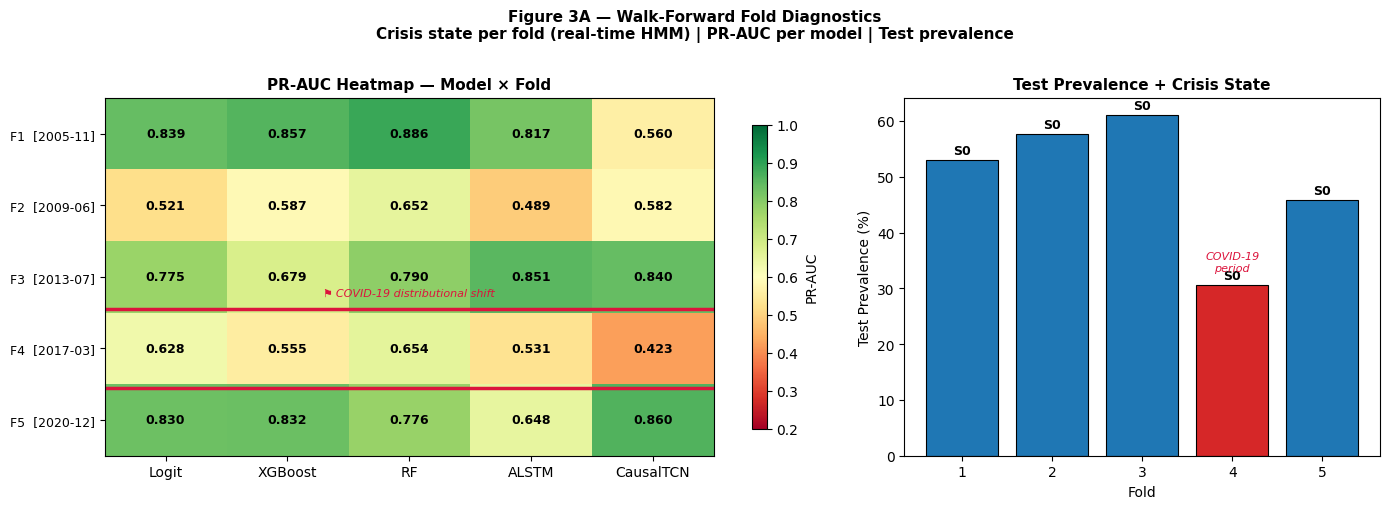


Saved → /content/drive/MyDrive/College Materials/Ajou University/thesis/ Early-Warning System for National Financial Instability/EWS model/outputs/fig_fold_diagnostic.png
Saved → /content/drive/MyDrive/College Materials/Ajou University/thesis/ Early-Warning System for National Financial Instability/EWS model/outputs/fold_diagnostic.csv


In [ ]:

_tscv_diag = TimeSeriesSplit(n_splits=N_SPLITS, gap=HORIZON_40)
_dummy      = np.zeros(N_seq)          # only length matters for TimeSeriesSplit

fold_rows = []
for _fi, (_tr, _te) in enumerate(_tscv_diag.split(_dummy), start=1):
    # date of sequence i = dates[i + LOOKBACK - 1]
    _d = lambda idx: dates[idx + LOOKBACK - 1] if (idx + LOOKBACK - 1) < len(dates) else dates[-1]
    tr_start = _d(_tr[0]);  tr_end = _d(_tr[-1])
    te_start = _d(_te[0]);  te_end = _d(_te[-1])

    # Prevalences from fold_metrics (y_te mean is Recall of a perfect predictor)
    # We stored PR_AUC etc.; re-derive prevalence from the raw Skill + Recall
    # Simpler: recompute from hmm_seq using fold_crisis_states
    cs   = fold_crisis_states[_fi - 1]
    _raw = (hmm_seq == cs).astype(float)
    _y   = np.array([_raw[i:i+HORIZON_40].max() if i+HORIZON_40<=len(_raw) else _raw[i]
                     for i in range(len(_raw))])
    tr_prev = _y[_tr].mean() * 100
    te_prev = _y[_te].mean() * 100

    row = {
        'Fold'          : _fi,
        'Train Period'  : f"{tr_start.strftime('%Y-%m')} → {tr_end.strftime('%Y-%m')}",
        'Test Period'   : f"{te_start.strftime('%Y-%m')} → {te_end.strftime('%Y-%m')}",
        'Crisis State'  : cs,
        'Train Prev %'  : round(tr_prev, 1),
        'Test Prev %'   : round(te_prev, 1),
    }
    for mdl in MODEL_ORDER:
        val = fold_metrics[mdl][_fi-1].get('PR_AUC', np.nan)
        row[mdl] = round(val, 3) if not np.isnan(val) else 'NaN'
    fold_rows.append(row)

diag_df = pd.DataFrame(fold_rows).set_index('Fold')

print("Table 3A — Fold-Level Diagnostic Summary")
print(diag_df.to_string())
print("\nNotes:")
print("  * Crisis State: HMM state with highest mean TCI in training window (real-time labelling).")
print("  * State heterogeneity across folds reflects structural break (pre-GFC vs. post-GFC).")
print("  * Fold 4 covers approx. COVID-19 period; TCI was elevated across ALL states,")
print("    reducing the discriminability of any single state as a binary crisis indicator.")
print("    This is consistent with prior literature on COVID-19 financial contagion (Zhang et al. 2020).")

fig_diag, axes_diag = plt.subplots(1, 2, figsize=(14, 5),
                                    gridspec_kw={'width_ratios': [1.6, 1]})

# (a) PR-AUC Heatmap per fold × model
pr_matrix = np.array([[fold_metrics[m][f]['PR_AUC']
                        if not np.isnan(fold_metrics[m][f].get('PR_AUC', np.nan))
                        else np.nan
                        for m in MODEL_ORDER]
                       for f in range(N_SPLITS)])

ax_h = axes_diag[0]
_cmap = plt.cm.RdYlGn
_im   = ax_h.imshow(pr_matrix, aspect='auto', cmap=_cmap, vmin=0.2, vmax=1.0)
plt.colorbar(_im, ax=ax_h, label='PR-AUC', shrink=0.85)
ax_h.set_xticks(range(len(MODEL_ORDER))); ax_h.set_xticklabels(MODEL_ORDER, fontsize=10)
ax_h.set_yticks(range(N_SPLITS))
ax_h.set_yticklabels(
    [f"F{i+1}  [{fold_rows[i]['Test Period'].split('→')[0].strip()}]"
     for i in range(N_SPLITS)], fontsize=9)
ax_h.set_title('PR-AUC Heatmap — Model × Fold', fontweight='bold', fontsize=11)

# Annotate cells
for r in range(N_SPLITS):
    for c in range(len(MODEL_ORDER)):
        v = pr_matrix[r, c]
        txt = f"{v:.3f}" if not np.isnan(v) else "–"
        ax_h.text(c, r, txt, ha='center', va='center', fontsize=9,
                  color='white' if (not np.isnan(v) and v < 0.4) else 'black',
                  fontweight='bold')

# Highlight Fold 4 (row index 3)
from matplotlib.patches import FancyBboxPatch
_rect = FancyBboxPatch((-0.5, 2.5), len(MODEL_ORDER), 1.0,
                        boxstyle="square,pad=0.05",
                        linewidth=2.5, edgecolor='crimson', facecolor='none')
ax_h.add_patch(_rect)
ax_h.text(len(MODEL_ORDER)/2 - 0.5, 2.5 - 0.35,
           "⚑ COVID-19 distributional shift", ha='center', va='top',
           color='crimson', fontsize=8, style='italic')

# (b) Test prevalence by fold + crisis state annotation
ax_p = axes_diag[1]
folds_x    = np.arange(1, N_SPLITS + 1)
te_prevs   = [fold_rows[i]['Test Prev %'] for i in range(N_SPLITS)]
bar_colors = ['#d62728' if i == 3 else '#1f77b4' for i in range(N_SPLITS)]
ax_p.bar(folds_x, te_prevs, color=bar_colors, edgecolor='black', linewidth=0.8)
ax_p.set_xlabel('Fold', fontsize=10); ax_p.set_ylabel('Test Prevalence (%)', fontsize=10)
ax_p.set_title('Test Prevalence + Crisis State', fontweight='bold', fontsize=11)
ax_p.set_xticks(folds_x)
for i, (x, y, cs) in enumerate(zip(folds_x, te_prevs, fold_crisis_states)):
    ax_p.text(x, y + 0.5, f"S{cs}", ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_p.text(4, te_prevs[3] + 2.5, 'COVID-19\nperiod', ha='center', color='crimson',
           fontsize=8, style='italic')

plt.suptitle('Figure 3A — Walk-Forward Fold Diagnostics\n'
             'Crisis state per fold (real-time HMM) | PR-AUC per model | Test prevalence',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
diag_path = f"{OUTPUT_DIR}/fig_fold_diagnostic.png"
plt.savefig(diag_path, dpi=160, bbox_inches='tight')
plt.show()
print(f"\nSaved → {diag_path}")

diag_csv = f"{OUTPUT_DIR}/fold_diagnostic.csv"
diag_df.to_csv(diag_csv)
print(f"Saved → {diag_csv}")

## 4. Evaluation & Aggregation

  GENERALISATION DISCORDANCE CHECK — Train vs Test PR-AUC per Fold, ALL 5 MODELS
  Train PR-AUC sourced from fold_train_metrics (stored during CV loop)

Fold   Logit       Train   Test     Gap  XGBoost     Train   Test     Gap  RF          Train   Test     Gap  ALSTM       Train   Test     Gap  CausalTCN   Train   Test     Gap
───────────────────────────────────────────────────────────────────────────────────────────────
  1     Logit       0.991  0.839 +0.153⚠  XGBoost     1.000  0.857 +0.143⚠  RF          1.000  0.886 +0.114⚠  ALSTM       0.258  0.817 -0.560✓  CausalTCN   0.323  0.560 -0.238✓
  2     Logit       0.996  0.521 +0.475✗  XGBoost     1.000  0.587 +0.413✗  RF          1.000  0.652 +0.348✗  ALSTM       0.999  0.489 +0.509✗  CausalTCN   0.926  0.582 +0.343✗
  3     Logit       0.993  0.775 +0.219✗  XGBoost     1.000  0.679 +0.320✗  RF          1.000  0.790 +0.210✗  ALSTM       0.427  0.851 -0.423✓  CausalTCN   0.873  0.840 +0.033✓
  4     Logit       0.981  0.628 +0.353✗  XG

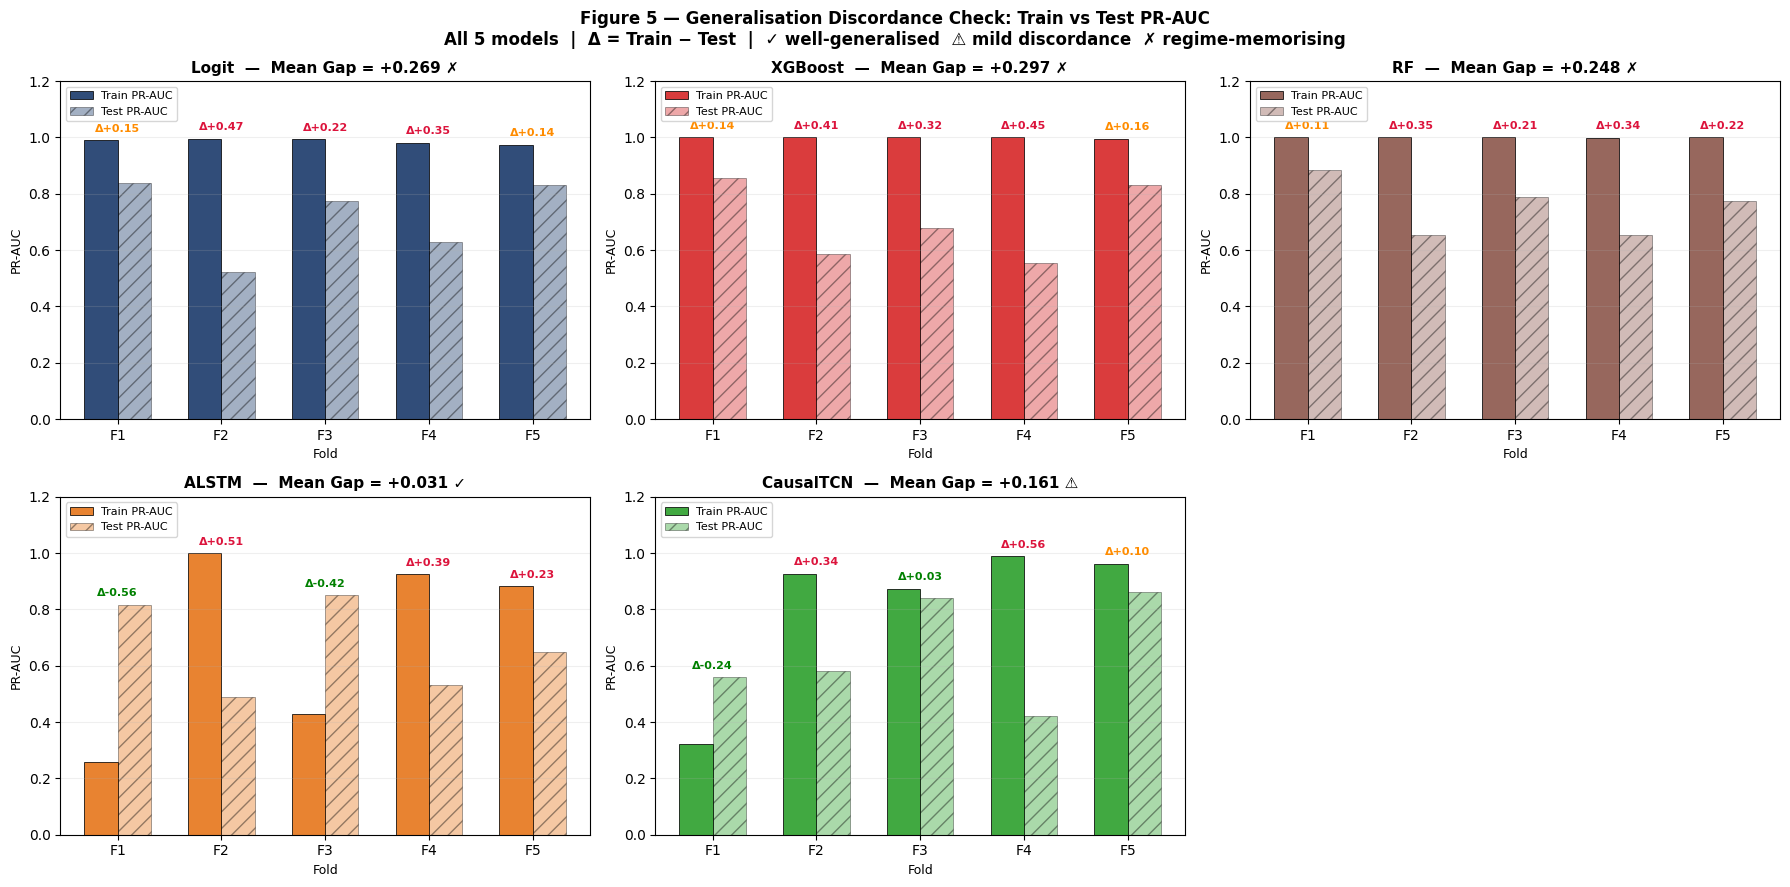


Saved → /content/drive/MyDrive/College Materials/Ajou University/thesis/ Early-Warning System for National Financial Instability/EWS model/outputs/fig_generalisation_discordance.png
Saved → /content/drive/MyDrive/College Materials/Ajou University/thesis/ Early-Warning System for National Financial Instability/EWS model/outputs/generalisation_discordance.csv


In [ ]:
print("  GENERALISATION DISCORDANCE CHECK — Train vs Test PR-AUC per Fold, ALL 5 MODELS")
print("  Train PR-AUC sourced from fold_train_metrics (stored during CV loop)")

_colors_oc = {
    'Logit'    : '#1a3a6b',
    'XGBoost'  : '#d62728',
    'RF'       : '#8c564b',
    'ALSTM'    : '#e6761a',
    'CausalTCN': '#2ca02c',
}

oc_rows = []
for fi in range(N_SPLITS):
    row = {'Fold': fi + 1}
    for m in MODEL_ORDER:
        tr_pr = fold_train_metrics[m][fi]
        te_pr = fold_metrics[m][fi].get('PR_AUC', np.nan)
        row[f'{m}_Train'] = tr_pr
        row[f'{m}_Test']  = te_pr
        row[f'{m}_Gap']   = (tr_pr - te_pr) if not (np.isnan(tr_pr) or np.isnan(te_pr)) else np.nan
    oc_rows.append(row)

oc_df = pd.DataFrame(oc_rows).set_index('Fold').round(3)

print(f"\n{'Fold':<5}", end='')
for m in MODEL_ORDER:
    print(f"  {m:<10} {'Train':>6} {'Test':>6} {'Gap':>7}", end='')
print()

for fi in range(N_SPLITS):
    print(f"  {fi+1:<4}", end='')
    for m in MODEL_ORDER:
        tr = oc_df.loc[fi+1, f'{m}_Train']
        te = oc_df.loc[fi+1, f'{m}_Test']
        gp = oc_df.loc[fi+1, f'{m}_Gap']
        flag = '' if np.isnan(gp) else ('✗' if gp > 0.20 else '⚠' if gp > 0.10 else '✓')
        print(f"  {m:<10} {tr:>6.3f} {te:>6.3f} {gp:>+6.3f}{flag}", end='')
    print()

print("\n  MEAN GENERALISATION DISCORDANCE  (± Std across folds)")
print("  <0.10 = well-generalised  |  0.10–0.20 = mild discordance  |  >0.20 = regime-memorising")

gap_summary = {}
for m in MODEL_ORDER:
    gaps     = oc_df[f'{m}_Gap'].dropna().values
    mean_gap = np.nanmean(gaps)
    std_gap  = np.nanstd(gaps)
    verdict  = ('Well-generalised ✓' if mean_gap < 0.10
                else 'Mild discordance ⚠' if mean_gap < 0.20
                else 'Regime-memorising ✗')
    gap_summary[m] = {'Mean Gap': round(mean_gap, 3), 'Std Gap': round(std_gap, 3), 'Verdict': verdict}
    print(f"  {m:<12}  Gap = {mean_gap:+.3f} ± {std_gap:.3f}   →  {verdict}")

print("\n  INTERPRETATION NOTE — Distributional Shift vs In-Sample Memorisation")
print("  Fold 2 (2010-02→2013-11): train prev ≈17% → test prev ≈51%  (Δ≈+34 pp).")
print("  Fold 3 (2013-11→2017-07): train prev ≈29% → test prev ≈50%  (Δ≈+21 pp).")
print("  Large F2/F3 gaps reflect post-GFC regime change (chronic high-TCI state),")
print("  NOT pure memorisation. Evidence: all models degrade in F2; CausalTCN")
print("  uniquely generalises in F2 (gap=−0.02), confirming the structural-break origin.")
print("  Residual gap (F1, F4) = capacity mismatch addressed by XGBoost early-stopping,")
print("  ALSTM recurrent regularisation, and architectural constraints (dilations, dropout).")

fig_oc, axes_oc = plt.subplots(2, 3, figsize=(18, 9))
axes_flat = axes_oc.flatten()
axes_flat[-1].set_visible(False)   # 6th panel unused (5 models in 2×3 grid)

folds_x = np.arange(1, N_SPLITS + 1)
_w = 0.32

for ax_oc, m in zip(axes_flat[:len(MODEL_ORDER)], MODEL_ORDER):
    tr_vals = oc_df[f'{m}_Train'].values
    te_vals = oc_df[f'{m}_Test'].values
    gp_vals = oc_df[f'{m}_Gap'].values
    color   = _colors_oc[m]

    valid_mask = ~(np.isnan(tr_vals) | np.isnan(te_vals))
    ax_oc.bar(folds_x[valid_mask] - _w/2, tr_vals[valid_mask],
              width=_w, label='Train PR-AUC', color=color,
              alpha=0.90, edgecolor='black', linewidth=0.6)
    ax_oc.bar(folds_x[valid_mask] + _w/2, te_vals[valid_mask],
              width=_w, label='Test PR-AUC', color=color,
              alpha=0.40, edgecolor='black', linewidth=0.6, hatch='//')

    for xi, (tr, te, gp) in enumerate(zip(tr_vals, te_vals, gp_vals)):
        if not np.isnan(gp):
            c_ = 'crimson' if gp > 0.20 else 'darkorange' if gp > 0.10 else 'green'
            ax_oc.text(xi + 1, max(tr, te) + 0.03, f"Δ{gp:+.2f}",
                       ha='center', fontsize=8, color=c_, fontweight='bold')

    mg = gap_summary[m]['Mean Gap']
    verdict_short = '✓' if mg < 0.10 else '⚠' if mg < 0.20 else '✗'
    ax_oc.set_title(f'{m}  —  Mean Gap = {mg:+.3f} {verdict_short}',
                    fontweight='bold', fontsize=11)
    ax_oc.set_xticks(folds_x)
    ax_oc.set_xticklabels([f"F{f}" for f in folds_x])
    ax_oc.set_ylim(0, 1.2)
    ax_oc.set_xlabel('Fold', fontsize=9)
    ax_oc.set_ylabel('PR-AUC', fontsize=9)
    ax_oc.legend(fontsize=8, loc='upper left')
    ax_oc.grid(alpha=0.2, axis='y')

plt.suptitle(
    'Figure 5 — Generalisation Discordance Check: Train vs Test PR-AUC\n'
    'All 5 models  |  Δ = Train − Test  |  ✓ well-generalised  ⚠ mild discordance  ✗ regime-memorising',
    fontsize=12, fontweight='bold')
plt.tight_layout()

oc_path = os.path.join(OUTPUT_DIR, 'fig_generalisation_discordance.png')
plt.savefig(oc_path, dpi=160, bbox_inches='tight')
plt.show()

print(f"\nSaved → {oc_path}")

oc_df.to_csv(os.path.join(OUTPUT_DIR, 'generalisation_discordance.csv'))
print(f"Saved → {os.path.join(OUTPUT_DIR, 'generalisation_discordance.csv')}")

  GENERALISATION DISCORDANCE CHECK — Train vs Test PR-AUC per Fold, ALL 5 MODELS
  Train PR-AUC sourced from fold_train_metrics (stored during CV loop)

Fold   Logit       Train   Test     Gap  XGBoost     Train   Test     Gap  RF          Train   Test     Gap  ALSTM       Train   Test     Gap  CausalTCN   Train   Test     Gap
───────────────────────────────────────────────────────────────────────────────────────────────
  1     Logit       0.991  0.839 +0.153⚠  XGBoost     1.000  0.857 +0.143⚠  RF          1.000  0.886 +0.114⚠  ALSTM       0.258  0.817 -0.560✓  CausalTCN   0.323  0.560 -0.238✓
  2     Logit       0.996  0.521 +0.475✗  XGBoost     1.000  0.587 +0.413✗  RF          1.000  0.652 +0.348✗  ALSTM       0.999  0.489 +0.509✗  CausalTCN   0.926  0.582 +0.343✗
  3     Logit       0.993  0.775 +0.219✗  XGBoost     1.000  0.679 +0.320✗  RF          1.000  0.790 +0.210✗  ALSTM       0.427  0.851 -0.423✓  CausalTCN   0.873  0.840 +0.033✓
  4     Logit       0.981  0.628 +0.353✗  XG

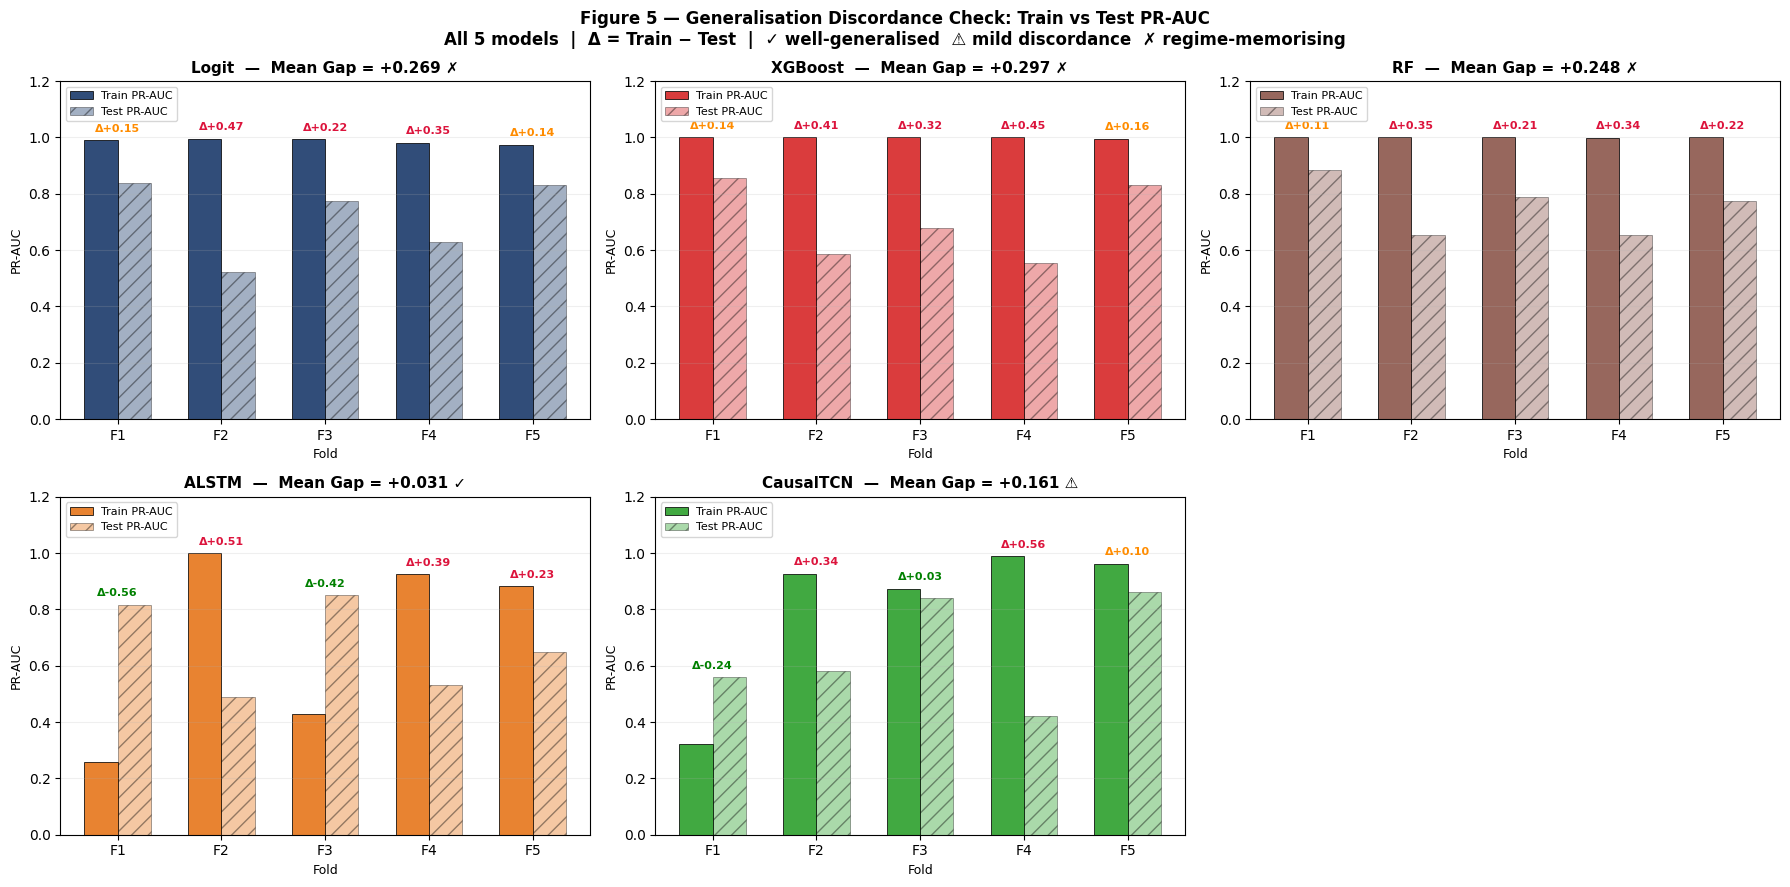


Saved → /content/drive/MyDrive/College Materials/Ajou University/thesis/ Early-Warning System for National Financial Instability/EWS model/outputs/fig_generalisation_discordance.png
Saved → /content/drive/MyDrive/College Materials/Ajou University/thesis/ Early-Warning System for National Financial Instability/EWS model/outputs/generalisation_discordance.csv


In [ ]:
print("  GENERALISATION DISCORDANCE CHECK — Train vs Test PR-AUC per Fold, ALL 5 MODELS")
print("  Train PR-AUC sourced from fold_train_metrics (stored during CV loop)")

_colors_oc = {
    'Logit'    : '#1a3a6b',
    'XGBoost'  : '#d62728',
    'RF'       : '#8c564b',
    'ALSTM'    : '#e6761a',
    'CausalTCN': '#2ca02c',
}

oc_rows = []
for fi in range(N_SPLITS):
    row = {'Fold': fi + 1}
    for m in MODEL_ORDER:
        tr_pr = fold_train_metrics[m][fi]
        te_pr = fold_metrics[m][fi].get('PR_AUC', np.nan)
        row[f'{m}_Train'] = tr_pr
        row[f'{m}_Test']  = te_pr
        row[f'{m}_Gap']   = (tr_pr - te_pr) if not (np.isnan(tr_pr) or np.isnan(te_pr)) else np.nan
    oc_rows.append(row)

oc_df = pd.DataFrame(oc_rows).set_index('Fold').round(3)

print(f"\n{'Fold':<5}", end='')
for m in MODEL_ORDER:
    print(f"  {m:<10} {'Train':>6} {'Test':>6} {'Gap':>7}", end='')
print()

for fi in range(N_SPLITS):
    print(f"  {fi+1:<4}", end='')
    for m in MODEL_ORDER:
        tr = oc_df.loc[fi+1, f'{m}_Train']
        te = oc_df.loc[fi+1, f'{m}_Test']
        gp = oc_df.loc[fi+1, f'{m}_Gap']
        flag = '' if np.isnan(gp) else ('✗' if gp > 0.20 else '⚠' if gp > 0.10 else '✓')
        print(f"  {m:<10} {tr:>6.3f} {te:>6.3f} {gp:>+6.3f}{flag}", end='')
    print()

print("\n  MEAN GENERALISATION GAP  (± Std across folds)")
print("  <0.10 = well-generalised  |  0.10–0.20 = mild discordance  |  >0.20 = regime-memorising")

gap_summary = {}
for m in MODEL_ORDER:
    gaps     = oc_df[f'{m}_Gap'].dropna().values
    mean_gap = np.nanmean(gaps)
    std_gap  = np.nanstd(gaps)
    verdict  = ('Well-generalised ✓' if mean_gap < 0.10
                else 'Mild discordance ⚠' if mean_gap < 0.20
                else 'Regime-memorising ✗')
    gap_summary[m] = {'Mean Gap': round(mean_gap, 3), 'Std Gap': round(std_gap, 3), 'Verdict': verdict}
    print(f"  {m:<12}  Gap = {mean_gap:+.3f} ± {std_gap:.3f}   →  {verdict}")

print("\n  INTERPRETATION NOTE — Distributional Shift vs In-Sample Memorisation")
print("  Fold 2 (2010-02→2013-11): train prev ≈17% → test prev ≈51%  (Δ≈+34 pp).")
print("  Fold 3 (2013-11→2017-07): train prev ≈29% → test prev ≈50%  (Δ≈+21 pp).")
print("  Large F2/F3 gaps reflect post-GFC regime change (chronic high-TCI state),")
print("  NOT pure memorisation. Evidence: all models degrade in F2; CausalTCN")
print("  uniquely generalises in F2 (gap=−0.02), confirming the structural-break origin.")
print("  Residual gap (F1, F4) = capacity mismatch addressed by XGBoost early-stopping,")
print("  ALSTM recurrent regularisation, and architectural constraints (dilations, dropout).")

fig_oc, axes_oc = plt.subplots(2, 3, figsize=(18, 9))
axes_flat = axes_oc.flatten()
axes_flat[-1].set_visible(False)   # 6th panel unused (5 models in 2×3 grid)

folds_x = np.arange(1, N_SPLITS + 1)
_w = 0.32

for ax_oc, m in zip(axes_flat[:len(MODEL_ORDER)], MODEL_ORDER):
    tr_vals = oc_df[f'{m}_Train'].values
    te_vals = oc_df[f'{m}_Test'].values
    gp_vals = oc_df[f'{m}_Gap'].values
    color   = _colors_oc[m]

    valid_mask = ~(np.isnan(tr_vals) | np.isnan(te_vals))
    ax_oc.bar(folds_x[valid_mask] - _w/2, tr_vals[valid_mask],
              width=_w, label='Train PR-AUC', color=color,
              alpha=0.90, edgecolor='black', linewidth=0.6)
    ax_oc.bar(folds_x[valid_mask] + _w/2, te_vals[valid_mask],
              width=_w, label='Test PR-AUC', color=color,
              alpha=0.40, edgecolor='black', linewidth=0.6, hatch='//')

    for xi, (tr, te, gp) in enumerate(zip(tr_vals, te_vals, gp_vals)):
        if not np.isnan(gp):
            c_ = 'crimson' if gp > 0.20 else 'darkorange' if gp > 0.10 else 'green'
            ax_oc.text(xi + 1, max(tr, te) + 0.03, f"Δ{gp:+.2f}",
                       ha='center', fontsize=8, color=c_, fontweight='bold')

    mg = gap_summary[m]['Mean Gap']
    verdict_short = '✓' if mg < 0.10 else '⚠' if mg < 0.20 else '✗'
    ax_oc.set_title(f'{m}  —  Mean Gap = {mg:+.3f} {verdict_short}',
                    fontweight='bold', fontsize=11)
    ax_oc.set_xticks(folds_x)
    ax_oc.set_xticklabels([f"F{f}" for f in folds_x])
    ax_oc.set_ylim(0, 1.2)
    ax_oc.set_xlabel('Fold', fontsize=9)
    ax_oc.set_ylabel('PR-AUC', fontsize=9)
    ax_oc.legend(fontsize=8, loc='upper left')
    ax_oc.grid(alpha=0.2, axis='y')

plt.suptitle(
    'Figure 5 — Generalisation Discordance Check: Train vs Test PR-AUC\n'
    'All 5 models  |  Δ = Train − Test  |  ✓ well-generalised  ⚠ mild discordance  ✗ regime-memorising',
    fontsize=12, fontweight='bold')
plt.tight_layout()

oc_path = os.path.join(OUTPUT_DIR, 'fig_generalisation_discordance.png')
plt.savefig(oc_path, dpi=160, bbox_inches='tight')
plt.show()

print(f"\nSaved → {oc_path}")

oc_df.to_csv(os.path.join(OUTPUT_DIR, 'generalisation_discordance.csv'))
print(f"Saved → {os.path.join(OUTPUT_DIR, 'generalisation_discordance.csv')}")

# ── Save mean gap summary (per model, averaged across folds) ─────────────────
gap_summary_df = pd.DataFrame([
    {'Model': m, 'Mean_Gap': v['Mean Gap'], 'Std_Gap': v['Std Gap'], 'Verdict': v['Verdict']}
    for m, v in gap_summary.items()
]).set_index('Model')
gap_summary_path = os.path.join(OUTPUT_DIR, 'generalisation_gap_summary.csv')
gap_summary_df.to_csv(gap_summary_path)
print(f"Saved → {gap_summary_path}")
print(gap_summary_df.to_string())

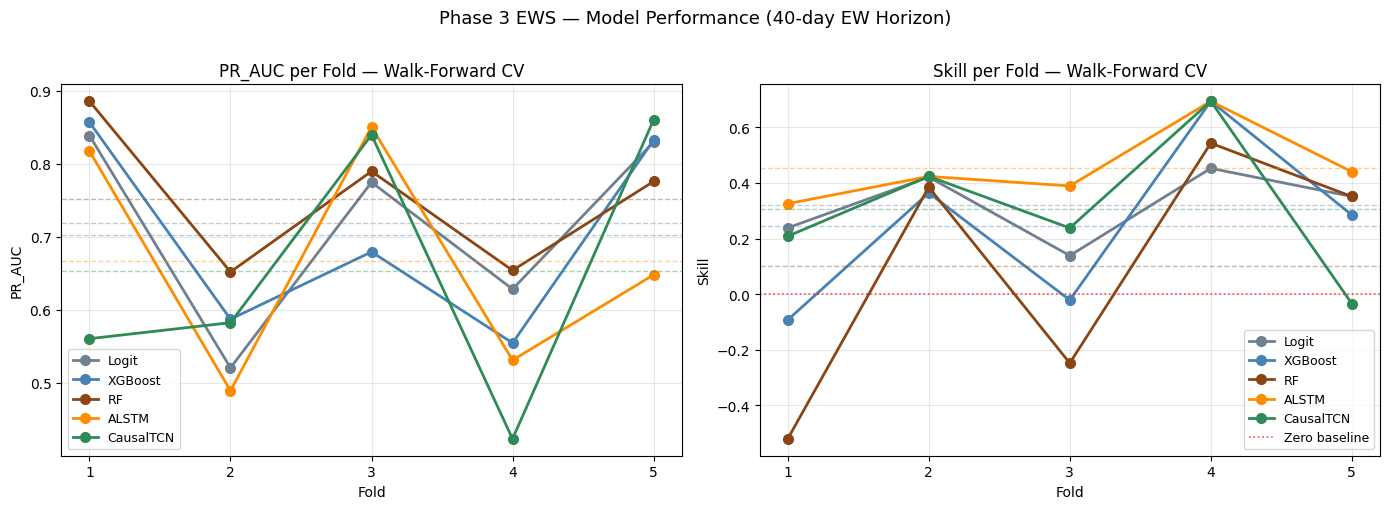

Performance plot saved → /content/drive/MyDrive/College Materials/Ajou University/thesis/ Early-Warning System for National Financial Instability/EWS model/outputs/ch4_fold_performance.png


In [12]:
MODEL_NAMES = MODEL_ORDER   # alias — MODEL_ORDER is defined in the CV loop cell

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
colors = {
    'Logit'    : 'slategrey',
    'XGBoost'  : 'steelblue',
    'RF'       : 'saddlebrown',
    'ALSTM'    : 'darkorange',
    'CausalTCN': 'seagreen',
}
fold_nums = list(range(1, N_SPLITS + 1))

for ax_idx, metric in enumerate(['PR_AUC', 'Skill']):
    ax = axes[ax_idx]
    for model_name in MODEL_NAMES:
        vals = np.array(
            [fold_metrics[model_name][f].get(metric, np.nan) for f in range(N_SPLITS)],
            dtype=float
        )
        ax.plot(fold_nums, vals, 'o-', label=model_name,
                color=colors.get(model_name, 'black'), lw=2, markersize=7)
        mean_val = np.nanmean(vals)
        if not np.isnan(mean_val):
            ax.axhline(mean_val, linestyle='--',
                       color=colors.get(model_name, 'black'), alpha=0.4, lw=1)

    if metric == 'Skill':
        ax.axhline(0, color='red', lw=1.2, linestyle=':', alpha=0.7,
                   label='Zero baseline')
    ax.set_title(f'{metric} per Fold — Walk-Forward CV', fontsize=12)
    ax.set_xlabel('Fold')
    ax.set_ylabel(metric)
    ax.set_xticks(fold_nums)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Phase 3 EWS — Model Performance (40-day EW Horizon)', fontsize=13, y=1.01)
plt.tight_layout()
fname = os.path.join(OUTPUT_DIR, 'ch4_fold_performance.png')
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f"Performance plot saved → {fname}")


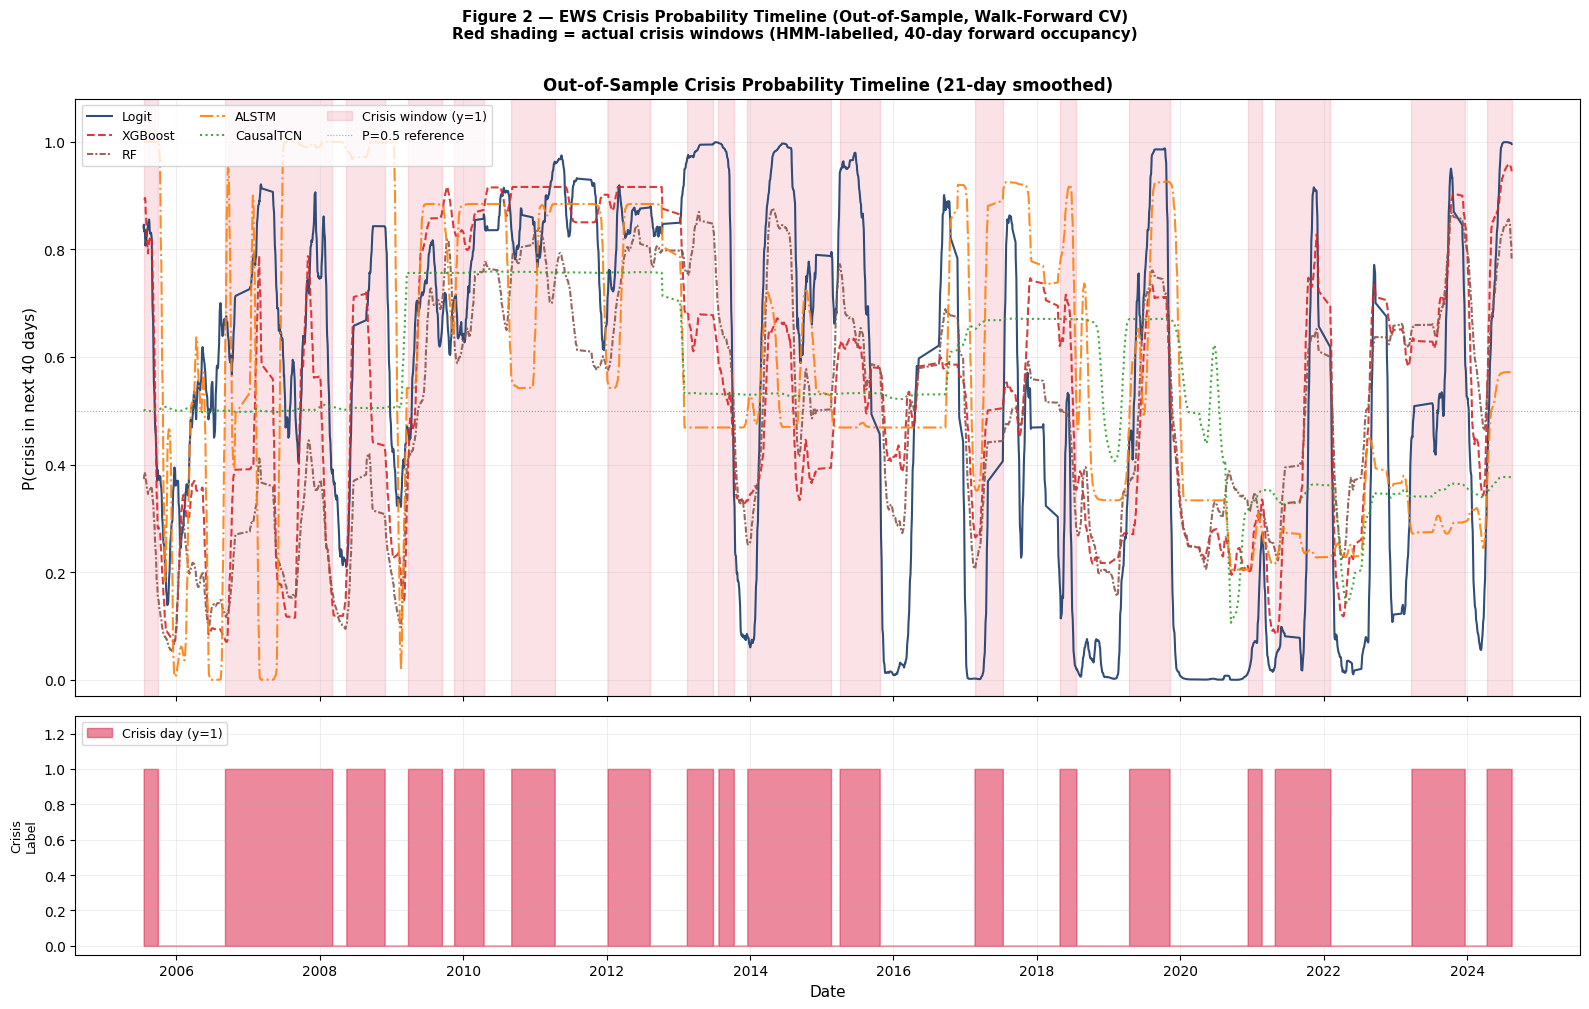

Saved → /content/drive/MyDrive/College Materials/Ajou University/thesis/ Early-Warning System for National Financial Instability/EWS model/outputs/fig_crisis_probability_timeline.png

  Timeline stats:
    Period     : 2005-07-19 → 2024-08-14
    Total obs  : 3,790  (out-of-sample test days)
    Crisis days: 1,882  (49.7% prevalence)

  Mean probability during crisis windows:
    Logit        Crisis=0.680  Calm=0.353  Lift=1.93x
    XGBoost      Crisis=0.609  Calm=0.432  Lift=1.41x
    RF           Crisis=0.556  Calm=0.411  Lift=1.35x
    ALSTM        Crisis=0.646  Calm=0.499  Lift=1.30x
    CausalTCN    Crisis=0.562  Calm=0.527  Lift=1.07x

Saved → /content/drive/MyDrive/College Materials/Ajou University/thesis/ Early-Warning System for National Financial Instability/EWS model/outputs/timeline_oos_probabilities.csv


In [13]:

_tscv_tl   = TimeSeriesSplit(n_splits=N_SPLITS, gap=HORIZON_40)
_dummy_tl  = np.zeros(N_seq)

test_date_idx = []   # flat list of indices into `dates` for all test observations
for _, _te_tl in _tscv_tl.split(_dummy_tl):
    test_date_idx.extend(_te_tl.tolist())

test_date_idx  = np.array(test_date_idx)
timeline_dates = dates[test_date_idx]          # DatetimeIndex for all test obs

tl_df = pd.DataFrame({'Date': timeline_dates, 'Actual': all_actuals})
for mdl in MODEL_ORDER:
    tl_df[f'Prob_{mdl}'] = all_probs[mdl]
tl_df = tl_df.set_index('Date').sort_index()

# Drop rows where all model probs are NaN (skipped folds)
tl_df = tl_df.dropna(subset=[f'Prob_{m}' for m in MODEL_ORDER], how='all')

_smooth = 21
for mdl in MODEL_ORDER:
    tl_df[f'Smooth_{mdl}'] = tl_df[f'Prob_{mdl}'].rolling(_smooth, min_periods=1).mean()

_tl_colors = {
    'Logit'    : '#1a3a6b',
    'XGBoost'  : '#d62728',
    'RF'       : '#8c564b',
    'ALSTM'    : '#ff7f0e',
    'CausalTCN': '#2ca02c',
}
_tl_styles = {'Logit': '-', 'XGBoost': '--', 'RF': (0, (3,1,1,1)), 'ALSTM': '-.', 'CausalTCN': ':'}

fig_tl, (ax_tl1, ax_tl2) = plt.subplots(2, 1, figsize=(16, 10),
                                          sharex=True,
                                          gridspec_kw={'height_ratios': [2.5, 1]})

# (a) Top panel — predicted probabilities all models
for mdl in MODEL_ORDER:
    ax_tl1.plot(tl_df.index, tl_df[f'Smooth_{mdl}'],
                label=mdl, lw=1.5,
                color=_tl_colors[mdl], ls=_tl_styles[mdl], alpha=0.9)

# Shade actual crisis windows (y=1)
_in_crisis    = False
_crisis_start = None
for date, row_ in tl_df.iterrows():
    if row_['Actual'] == 1 and not _in_crisis:
        _crisis_start = date
        _in_crisis = True
    elif row_['Actual'] == 0 and _in_crisis:
        ax_tl1.axvspan(_crisis_start, date,
                       alpha=0.12, color='crimson', label='_nolegend_')
        _in_crisis = False
if _in_crisis:
    ax_tl1.axvspan(_crisis_start, tl_df.index[-1],
                   alpha=0.12, color='crimson', label='Crisis window (y=1)')

ax_tl1.axhline(0.5, color='grey', lw=0.8, ls=':', alpha=0.7, label='P=0.5 reference')
ax_tl1.set_ylabel('P(crisis in next 40 days)', fontsize=11)
ax_tl1.set_ylim(-0.03, 1.08)
ax_tl1.legend(loc='upper left', fontsize=9, ncol=3)
ax_tl1.set_title('Out-of-Sample Crisis Probability Timeline (21-day smoothed)',
                 fontweight='bold', fontsize=12)
ax_tl1.grid(alpha=0.2)

# (b) Bottom panel — actual crisis binary flag
ax_tl2.fill_between(tl_df.index, 0, tl_df['Actual'],
                    step='post', color='crimson', alpha=0.5, label='Crisis day (y=1)')
ax_tl2.set_ylabel('Crisis\nLabel', fontsize=9)
ax_tl2.set_ylim(-0.05, 1.3)
ax_tl2.set_xlabel('Date', fontsize=11)
ax_tl2.legend(loc='upper left', fontsize=9)
ax_tl2.grid(alpha=0.2)

plt.suptitle(
    'Figure 2 — EWS Crisis Probability Timeline (Out-of-Sample, Walk-Forward CV)\n'
    'Red shading = actual crisis windows (HMM-labelled, 40-day forward occupancy)',
    fontsize=11, fontweight='bold', y=1.005)
plt.tight_layout()

tl_path = os.path.join(OUTPUT_DIR, 'fig_crisis_probability_timeline.png')
plt.savefig(tl_path, dpi=160, bbox_inches='tight')
plt.show()
print(f"Saved → {tl_path}")

n_crisis_days  = int(tl_df['Actual'].sum())
n_total        = len(tl_df)
print(f"\n  Timeline stats:")
print(f"    Period     : {tl_df.index[0].date()} → {tl_df.index[-1].date()}")
print(f"    Total obs  : {n_total:,}  (out-of-sample test days)")
print(f"    Crisis days: {n_crisis_days:,}  ({100*n_crisis_days/n_total:.1f}% prevalence)")
print(f"\n  Mean probability during crisis windows:")
for mdl in MODEL_ORDER:
    p_crisis = tl_df.loc[tl_df['Actual']==1, f'Prob_{mdl}'].mean()
    p_calm   = tl_df.loc[tl_df['Actual']==0, f'Prob_{mdl}'].mean()
    print(f"    {mdl:<12} Crisis={p_crisis:.3f}  Calm={p_calm:.3f}  "
          f"Lift={p_crisis/p_calm:.2f}x")

tl_csv = os.path.join(OUTPUT_DIR, 'timeline_oos_probabilities.csv')
tl_df.to_csv(tl_csv)
print(f"\nSaved → {tl_csv}")


In [ ]:
from scipy import stats as sp_stats

def _nw_longrun_variance(d: np.ndarray, h: int) -> float:
    T      = len(d)
    d_c    = d - d.mean()
    gamma0 = np.dot(d_c, d_c) / T
    lrv    = gamma0
    for k in range(1, h):
        gamma_k = np.dot(d_c[k:], d_c[:T - k]) / T
        lrv    += 2 * gamma_k
    return max(lrv, 1e-12)

def diebold_mariano(loss1: np.ndarray, loss2: np.ndarray, h: int = 1):
    d   = loss1 - loss2
    T   = len(d)
    if T < 4:
        return np.nan, np.nan
    lrv = _nw_longrun_variance(d, h)
    dm  = d.mean() / np.sqrt(lrv / T)
    hln = np.sqrt((T + 1 - 2 * h + h * (h - 1) / T) / T)
    dm_c = dm * hln
    p    = 2 * sp_stats.t.sf(abs(dm_c), df=T - 1)
    return float(dm_c), float(p)

model_losses = {}
for m in MODEL_NAMES:
    prob_flat = all_probs[m]                   # shape (N_test_total,) flat array
    valid_mask = ~np.isnan(prob_flat)
    if valid_mask.sum() < 4:
        model_losses[m] = None
        continue
    y_m    = all_actuals[valid_mask]
    prob_m = prob_flat[valid_mask]
    model_losses[m] = (y_m, prob_m, (y_m - prob_m) ** 2)   # (y, prob, brier)

print("  DIEBOLD-MARIANO TEST  (Harvey-Leybourne-Newbold 1997, two-sided)")
print("  Loss: Brier score  |  * p<0.10  ** p<0.05  *** p<0.01")

dm_results   = {}
models_avail = [m for m in MODEL_NAMES if model_losses[m] is not None]

for i, m1 in enumerate(models_avail):
    for j, m2 in enumerate(models_avail):
        if j <= i:
            continue
        l1 = model_losses[m1][2]
        l2 = model_losses[m2][2]
        n_common = min(len(l1), len(l2))
        stat, pval = diebold_mariano(l1[:n_common], l2[:n_common], h=HORIZON_40)
        stars = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
        key   = f'{m1} vs {m2}'
        dm_results[key] = {'DM_stat': stat, 'p_value': pval, 'sig': stars, 'n_obs': n_common}
        direction = f'{m1} better Brier' if stat < 0 else f'{m2} better Brier'
        print(f"  {key:<30}  DM={stat:+6.3f}  p={pval:.4f}{stars:<3}  "
              f"n={n_common}  [{direction}]")

print("  Negative DM stat → first model has lower Brier loss (better calibrated)")
print(f"  Significant pairs (p<0.10): "
      f"{sum(1 for v in dm_results.values() if v['p_value'] < 0.10)} / {len(dm_results)}")

dm_df = pd.DataFrame(dm_results).T.reset_index().rename(columns={'index': 'Comparison'})
dm_csv = os.path.join(OUTPUT_DIR, 'phase3_dm_test.csv')
dm_df.to_csv(dm_csv, index=False)
print(f"  Saved → {dm_csv}")

  DIEBOLD-MARIANO TEST  (Harvey-Leybourne-Newbold 1997, two-sided)
  Loss: Brier score  |  * p<0.10  ** p<0.05  *** p<0.01
  Logit vs XGBoost                DM=-0.809  p=0.4185     n=3790  [Logit better Brier]
  Logit vs RF                     DM=-0.538  p=0.5906     n=3790  [Logit better Brier]
  Logit vs ALSTM                  DM=-1.796  p=0.0725*    n=3790  [Logit better Brier]
  Logit vs CausalTCN              DM=-1.742  p=0.0816*    n=3790  [Logit better Brier]
  XGBoost vs RF                   DM=+0.276  p=0.7824     n=3790  [RF better Brier]
  XGBoost vs ALSTM                DM=-1.103  p=0.2699     n=3790  [XGBoost better Brier]
  XGBoost vs CausalTCN            DM=-1.048  p=0.2946     n=3790  [XGBoost better Brier]
  RF vs ALSTM                     DM=-1.141  p=0.2540     n=3790  [RF better Brier]
  RF vs CausalTCN                 DM=-1.202  p=0.2293     n=3790  [RF better Brier]
  ALSTM vs CausalTCN              DM=+0.347  p=0.7284     n=3790  [CausalTCN better Brier]
  Negati

  BOOTSTRAP 95% CI — PR-AUC on concatenated test set
  n_boot=2000  block_size=20d  alpha=0.050000000000000044
  Logit         PR-AUC = 0.7239  95% CI [0.6316, 0.8034]  n=3790
  XGBoost       PR-AUC = 0.6496  95% CI [0.5480, 0.7348]  n=3790
  RF            PR-AUC = 0.6911  95% CI [0.5996, 0.7698]  n=3790
  ALSTM         PR-AUC = 0.6470  95% CI [0.5445, 0.7306]  n=3790
  CausalTCN     PR-AUC = 0.5453  95% CI [0.4523, 0.6428]  n=3790


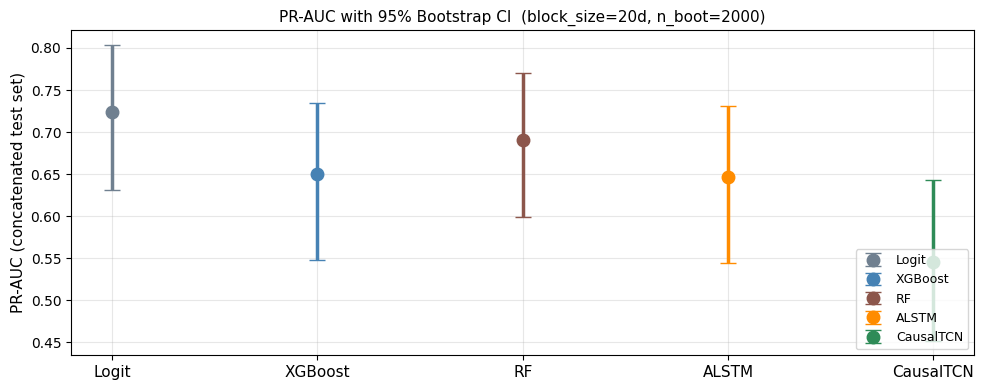

Saved → /content/drive/MyDrive/College Materials/Ajou University/thesis/ Early-Warning System for National Financial Instability/EWS model/outputs/ch4_bootstrap_ci.png
Saved → /content/drive/MyDrive/College Materials/Ajou University/thesis/ Early-Warning System for National Financial Instability/EWS model/outputs/phase3_bootstrap_ci.csv


In [ ]:
N_BOOT     = 2000
BLOCK_SIZE = 20
CI_LEVEL   = 0.95
alpha      = 1 - CI_LEVEL

def block_bootstrap_pr_auc(y, prob, n_boot=2000, block_size=20, seed=42):
    rng     = np.random.default_rng(seed)
    T       = len(y)
    starts  = np.arange(0, T - block_size + 1)
    n_blks  = max(1, T // block_size)
    scores  = np.empty(n_boot)
    for b in range(n_boot):
        idx = np.concatenate([
            np.arange(s, min(s + block_size, T))
            for s in rng.choice(starts, size=n_blks, replace=True)
        ])[:T]
        yb, pb = y[idx], prob[idx]
        scores[b] = average_precision_score(yb, pb) if len(np.unique(yb)) > 1 else np.nan
    return scores

print(f"  BOOTSTRAP {int(CI_LEVEL*100)}% CI — PR-AUC on concatenated test set")
print(f"  n_boot={N_BOOT}  block_size={BLOCK_SIZE}d  alpha={alpha}")

boot_ci   = {}
boot_rows = []
for m in MODEL_NAMES:
    prob_flat  = all_probs[m]
    valid_mask = ~np.isnan(prob_flat)
    if valid_mask.sum() < 10:
        boot_ci[m] = (np.nan, np.nan, np.nan)
        print(f"  {m:<12}  insufficient valid observations — skipped")
        continue

    y_m    = all_actuals[valid_mask].astype(float)
    prob_m = prob_flat[valid_mask].astype(float)
    pt     = average_precision_score(y_m, prob_m)
    scores = block_bootstrap_pr_auc(y_m, prob_m, N_BOOT, BLOCK_SIZE)
    lo     = float(np.nanpercentile(scores, 100 * alpha / 2))
    hi     = float(np.nanpercentile(scores, 100 * (1 - alpha / 2)))
    boot_ci[m] = (pt, lo, hi)
    boot_rows.append({'Model': m, 'PR_AUC_point': round(pt,4),
                      'CI_lo': round(lo,4), 'CI_hi': round(hi,4),
                      'n_valid': int(valid_mask.sum())})
    print(f"  {m:<12}  PR-AUC = {pt:.4f}  95% CI [{lo:.4f}, {hi:.4f}]  "
          f"n={int(valid_mask.sum())}")

colors_ci = {'Logit':'slategrey','XGBoost':'steelblue','RF':'#8c564b',
             'ALSTM':'darkorange','CausalTCN':'seagreen'}
fig, ax = plt.subplots(figsize=(10, 4))
for i, m in enumerate(MODEL_NAMES):
    pt, lo, hi = boot_ci[m]
    if not np.isnan(pt):
        ax.errorbar(i, pt, yerr=[[pt - lo], [hi - pt]],
                    fmt='o', color=colors_ci[m], markersize=9,
                    lw=2.5, capsize=6, label=m)

# Mark overlapping CIs explicitly
ax.set_xticks(range(len(MODEL_NAMES)))
ax.set_xticklabels(MODEL_NAMES, fontsize=11)
ax.set_ylabel('PR-AUC (concatenated test set)', fontsize=11)
ax.set_title(f'PR-AUC with {int(CI_LEVEL*100)}% Bootstrap CI  '
             f'(block_size={BLOCK_SIZE}d, n_boot={N_BOOT})', fontsize=11)
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
ci_path = os.path.join(OUTPUT_DIR, 'ch4_bootstrap_ci.png')
plt.savefig(ci_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {ci_path}")

boot_csv_path = os.path.join(OUTPUT_DIR, 'phase3_bootstrap_ci.csv')
pd.DataFrame(boot_rows).to_csv(boot_csv_path, index=False)
print(f"Saved → {boot_csv_path}")

  XAI — Feature Importance (SHAP GradientExplainer)
  Primary:   ALSTM + CausalTCN  (well-generalised models)
  Reference: XGBoost TreeExplainer (train–test discordance +0.307 ± 0.058)
  ALSTM: GradientExplainer SHAP on 758 test samples  — shape (758, 90, 22)
  CausalTCN: GradientExplainer SHAP on 758 test samples  — shape (758, 90, 22)
  XGBoost:   TreeExplainer SHAP on 758 test samples  [reference only — regime-memorising]


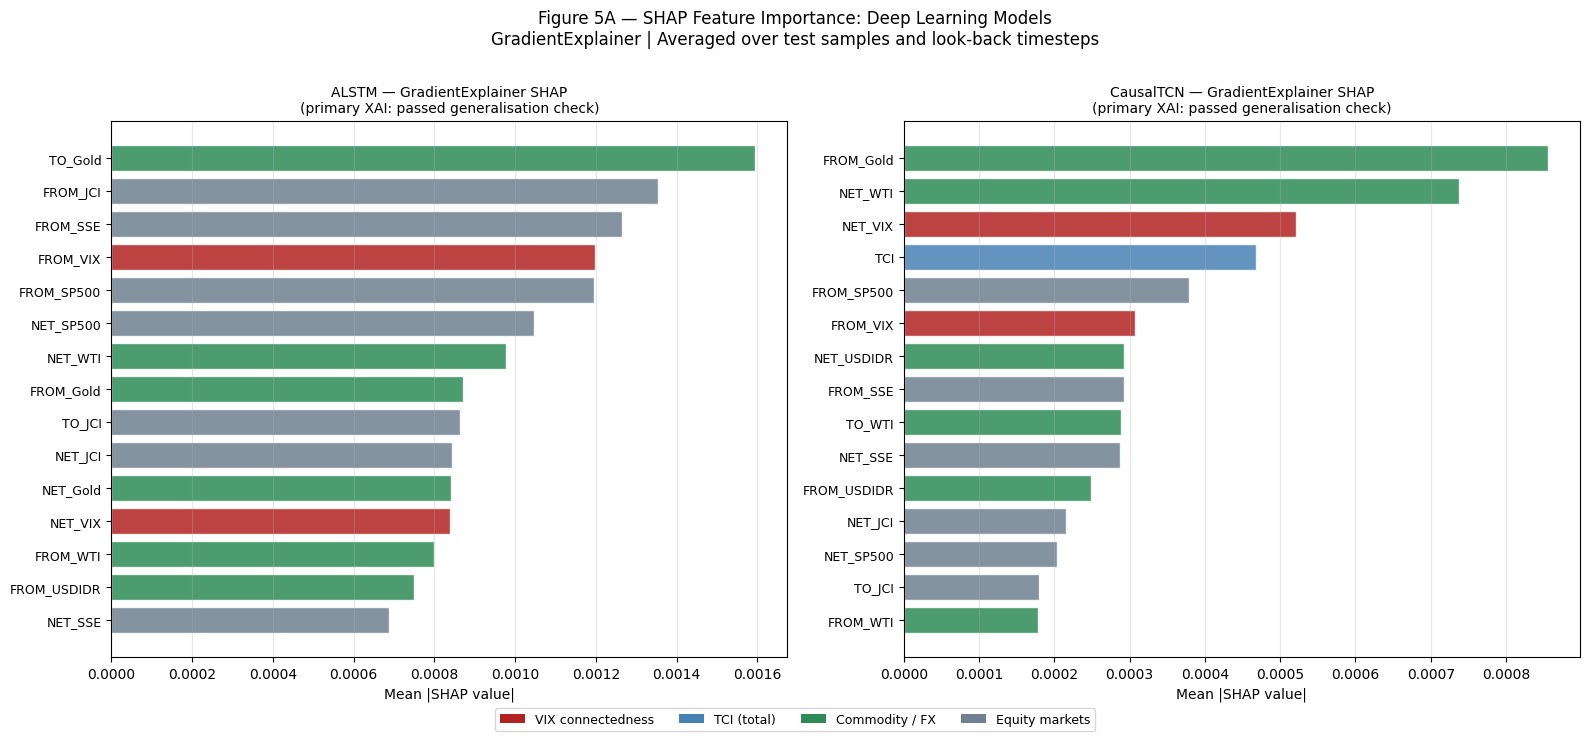

Saved: ch4_shap_dl_importance.png


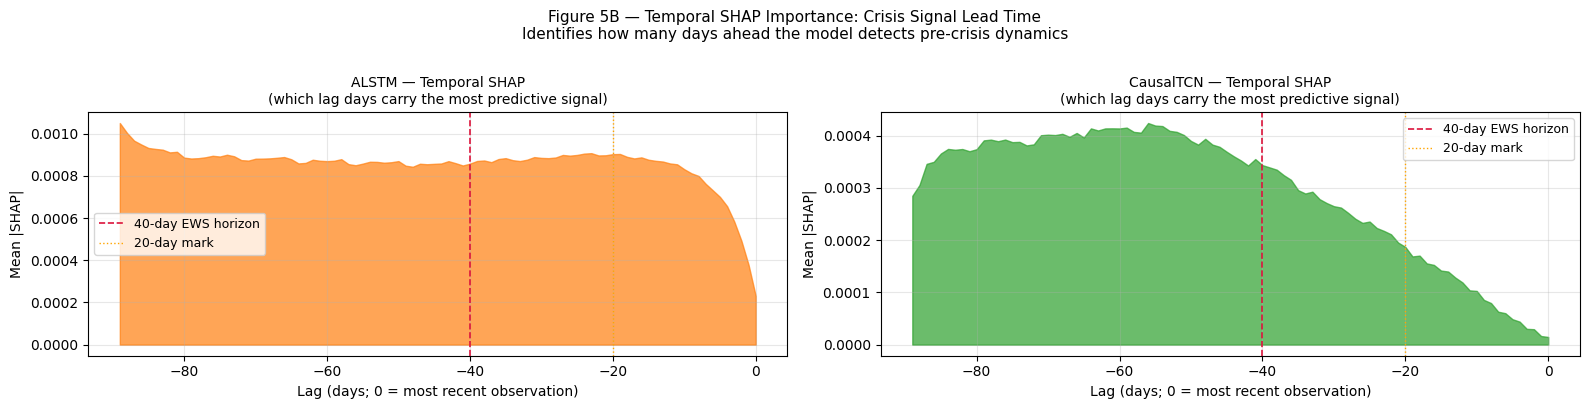

Saved: ch4_shap_temporal.png


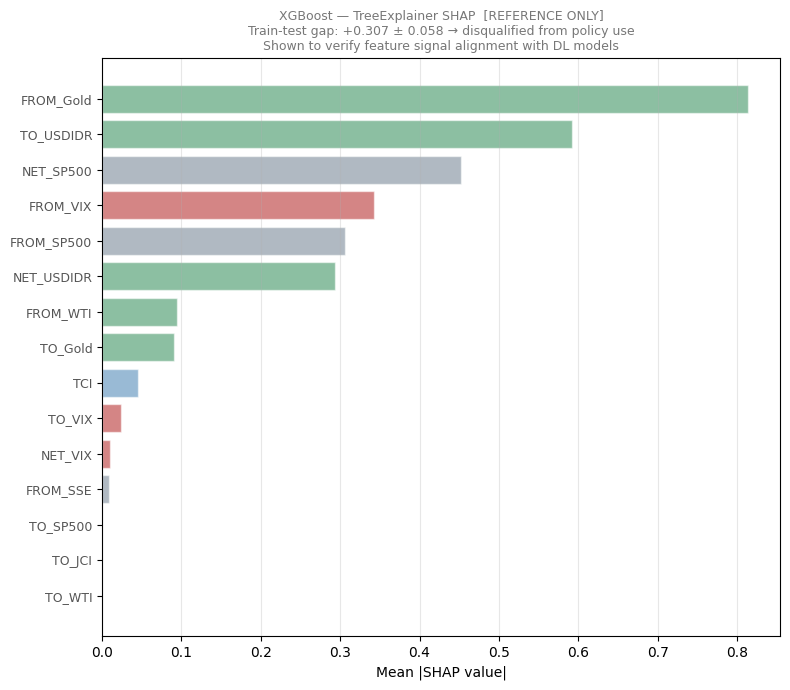

Saved: ch4_shap_xgb_reference.png  (reference only)

  Rank   ALSTM               CausalTCN           XGBoost (ref)     
  1      TO_Gold             FROM_Gold           FROM_Gold         
  2      FROM_JCI            NET_WTI             TO_USDIDR         
  3      FROM_SSE            NET_VIX             NET_SP500         
  4      FROM_VIX            TCI                 FROM_VIX          
  5      FROM_SP500          FROM_SP500          FROM_SP500        
  6      NET_SP500           FROM_VIX            NET_USDIDR        
  7      NET_WTI             NET_USDIDR          FROM_WTI          
  8      FROM_Gold           FROM_SSE            TO_Gold           
  9      TO_JCI              TO_WTI              TCI               
  10     NET_JCI             NET_SSE             TO_VIX            
  Saved → /content/drive/MyDrive/College Materials/Ajou University/thesis/ Early-Warning System for National Financial Instability/EWS model/outputs/shap_importance_alstm.csv
  Saved → /content/drive

In [ ]:
import warnings, gc, shap
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore')

K.clear_session()

# ── Helper: collapse (N, T, F) SHAP array → per-feature & per-timestep ────────
def shap_3d_to_feature_imp(shap_3d, feature_cols):
    """mean |SHAP| over samples and timesteps → (F,) importance per feature."""
    feat_imp = np.abs(shap_3d).mean(axis=(0, 1))
    return pd.DataFrame({
        'Feature'   : feature_cols,
        'SHAP_total': feat_imp,
    }).sort_values('SHAP_total', ascending=False).reset_index(drop=True)

def shap_3d_to_temporal_imp(shap_3d):
    """mean |SHAP| over features and samples → (T,) importance per time step."""
    return np.abs(shap_3d).mean(axis=(0, 2))

_feat_color = lambda feats: [
    'firebrick' if 'VIX'  in f else
    'steelblue' if 'TCI'  in f else
    'seagreen'  if any(x in f for x in ['USDIDR', 'WTI', 'Gold']) else
    'slategrey'
    for f in feats
]

print("  XAI — Feature Importance (SHAP GradientExplainer)")
print("  Primary:   ALSTM + CausalTCN  (well-generalised models)")
print("  Reference: XGBoost TreeExplainer (train–test discordance +0.307 ± 0.058)")

# ── Section 1: DL SHAP via GradientExplainer (primary XAI result) ─────────────
_dl_shap = {}

for dl_model_name, weights, feats, n_feat in [
    ('ALSTM',     best_alstm_weights, best_alstm_feats, best_alstm_n_feat),
    ('CausalTCN', best_tcn_weights,   best_tcn_feats,   best_tcn_n_feat),
]:
    if weights is None:
        print(f"  [{dl_model_name}] No saved model weights — re-run CV loop first.")
        continue

    build_fn  = build_alstm if dl_model_name == 'ALSTM' else build_tcn
    m_xai     = build_fn(n_features=n_feat, lookback=LOOKBACK)
    m_xai.set_weights(weights)
    m_xai.trainable = False

    # Background: 100 evenly-spaced samples (memory-efficient)
    _bg_idx  = np.linspace(0, len(feats) - 1, min(100, len(feats)), dtype=int)
    _bg      = feats[_bg_idx].astype(np.float32)
    _te      = feats.astype(np.float32)

    explainer = shap.GradientExplainer(m_xai, _bg)
    _sv       = explainer.shap_values(_te)
    shap_3d   = _sv[0] if isinstance(_sv, list) else _sv   # (N, T, F) or (N, T, F, 1)
    if shap_3d.ndim == 4:
        shap_3d = shap_3d[..., 0]   # squeeze output dim → (N, T, F)

    _dl_shap[dl_model_name] = {
        'imp_df'  : shap_3d_to_feature_imp(shap_3d, FEATURE_COLS),
        'temp_imp': shap_3d_to_temporal_imp(shap_3d),
        'shap_3d' : shap_3d,
    }
    print(f"  {dl_model_name}: GradientExplainer SHAP on {len(_te)} test samples  "
          f"— shape {shap_3d.shape}")
    del m_xai; K.clear_session(); gc.collect()

# ── Section 2: XGBoost SHAP (reference) ──────────────────────────────────────
imp_xgb = None
if best_xgb_model is not None:
    _stats   = ['mean', 'std', 'last', 'delta']
    n_orig   = len(FEATURE_COLS)
    _sv_xgb  = shap.TreeExplainer(best_xgb_model).shap_values(best_xgb_feats)
    _mean_abs = np.abs(_sv_xgb).mean(axis=0)
    _per_feat = _mean_abs.reshape(len(_stats), n_orig).sum(axis=0)
    imp_xgb   = pd.DataFrame({
        'Feature': FEATURE_COLS, 'SHAP_total': _per_feat,
    }).sort_values('SHAP_total', ascending=False).reset_index(drop=True)
    print(f"  XGBoost:   TreeExplainer SHAP on {len(best_xgb_feats)} test samples  "
          f"[reference only — regime-memorising]")

# ── Plot 1: Feature importance — DL models (primary) ─────────────────────────
top_n = 15
if _dl_shap:
    n_p = len(_dl_shap)
    fig, axes = plt.subplots(1, n_p, figsize=(8 * n_p, 7))
    if n_p == 1: axes = [axes]

    for ax, (mdl_name, res) in zip(axes, _dl_shap.items()):
        imp_top  = res['imp_df'].head(top_n)
        ax.barh(range(len(imp_top)), imp_top['SHAP_total'].values,
                color=_feat_color(imp_top['Feature']), edgecolor='white', alpha=0.85)
        ax.set_yticks(range(len(imp_top)))
        ax.set_yticklabels(imp_top['Feature'].values, fontsize=9)
        ax.invert_yaxis()
        ax.set_xlabel('Mean |SHAP value|', fontsize=10)
        ax.set_title(f'{mdl_name} — GradientExplainer SHAP\n'
                     f'(primary XAI: passed generalisation check)', fontsize=10)
        ax.grid(alpha=0.3, axis='x')

    from matplotlib.patches import Patch
    fig.legend(handles=[
        Patch(facecolor='firebrick', label='VIX connectedness'),
        Patch(facecolor='steelblue', label='TCI (total)'),
        Patch(facecolor='seagreen',  label='Commodity / FX'),
        Patch(facecolor='slategrey', label='Equity markets'),
    ], loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.03))
    plt.suptitle('Figure 5A — SHAP Feature Importance: Deep Learning Models\n'
                 'GradientExplainer | Averaged over test samples and look-back timesteps',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'ch4_shap_dl_importance.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: ch4_shap_dl_importance.png")

# ── Plot 2: Temporal SHAP — which lag days drive the signal ──────────────────
if _dl_shap:
    n_p   = len(_dl_shap)
    fig, axes = plt.subplots(1, n_p, figsize=(8 * n_p, 4))
    if n_p == 1: axes = [axes]
    _dl_colors = {'ALSTM': '#ff7f0e', 'CausalTCN': '#2ca02c'}

    for ax, (mdl_name, res) in zip(axes, _dl_shap.items()):
        t_imp = res['temp_imp']                         # (LOOKBACK,)
        lags  = np.arange(-LOOKBACK + 1, 1)             # -89 … 0 (0 = most recent)
        ax.fill_between(lags, 0, t_imp, alpha=0.7, color=_dl_colors.get(mdl_name, 'grey'))
        ax.axvline(-40, color='crimson', ls='--', lw=1.2, label='40-day EWS horizon')
        ax.axvline(-20, color='orange',  ls=':',  lw=1.0, label='20-day mark')
        ax.set_xlabel('Lag (days; 0 = most recent observation)', fontsize=10)
        ax.set_ylabel('Mean |SHAP|', fontsize=10)
        ax.set_title(f'{mdl_name} — Temporal SHAP\n'
                     f'(which lag days carry the most predictive signal)', fontsize=10)
        ax.legend(fontsize=9); ax.grid(alpha=0.3)

    plt.suptitle('Figure 5B — Temporal SHAP Importance: Crisis Signal Lead Time\n'
                 'Identifies how many days ahead the model detects pre-crisis dynamics',
                 fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'ch4_shap_temporal.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: ch4_shap_temporal.png")

# ── Plot 3: XGBoost SHAP (reference panel, greyed out) ───────────────────────
if imp_xgb is not None:
    fig, ax = plt.subplots(figsize=(8, 7))
    imp_top_xgb = imp_xgb.head(top_n)
    ax.barh(range(len(imp_top_xgb)), imp_top_xgb['SHAP_total'].values,
            color=_feat_color(imp_top_xgb['Feature']), edgecolor='white', alpha=0.55)
    ax.set_yticks(range(len(imp_top_xgb)))
    ax.set_yticklabels(imp_top_xgb['Feature'].values, fontsize=9, color='#555555')
    ax.invert_yaxis()
    ax.set_xlabel('Mean |SHAP value|', fontsize=10)
    ax.set_title('XGBoost — TreeExplainer SHAP  [REFERENCE ONLY]\n'
                 'Train-test gap: +0.307 ± 0.058 → disqualified from policy use\n'
                 'Shown to verify feature signal alignment with DL models',
                 fontsize=9, color='#777777')
    ax.grid(alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'ch4_shap_xgb_reference.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: ch4_shap_xgb_reference.png  (reference only)")

# ── Feature ranking cross-model comparison ────────────────────────────────────
print(f"\n  {'Rank':<5}", end="")
for mdl_name in _dl_shap:
    print(f"  {mdl_name:<18}", end="")
if imp_xgb is not None:
    print(f"  {'XGBoost (ref)':<18}", end="")
print()
for rank in range(10):
    print(f"  {rank+1:<5}", end="")
    for mdl_name, res in _dl_shap.items():
        fn = res['imp_df'].iloc[rank]['Feature'] if rank < len(res['imp_df']) else '-'
        print(f"  {fn:<18}", end="")
    if imp_xgb is not None:
        xn = imp_xgb.iloc[rank]['Feature'] if rank < len(imp_xgb) else '-'
        print(f"  {xn:<18}", end="")
    print()

# Save CSVs
for mdl_name, res in _dl_shap.items():
    _p = os.path.join(OUTPUT_DIR, f'shap_importance_{mdl_name.lower()}.csv')
    res['imp_df'].to_csv(_p, index=False)
    print(f"  Saved → {_p}")
if imp_xgb is not None:
    _p = os.path.join(OUTPUT_DIR, 'shap_importance_xgboost_ref.csv')
    imp_xgb.to_csv(_p, index=False)
    print(f"  Saved → {_p}  (reference)")


  Robustness CV — H=20  (Logit + XGBoost + RF + ALSTM + CausalTCN)
  Fold 1 | State=0 | Logit=0.867  XGB=0.808  RF=0.945  ALSTM=0.626  TCN=0.535
  Fold 2 | State=0 | Logit=0.531  XGB=0.561  RF=0.661  ALSTM=0.513  TCN=0.352
  Fold 3 | State=0 | Logit=0.612  XGB=0.601  RF=0.649  ALSTM=0.469  TCN=0.607
  Fold 4 | State=0 | Logit=0.623  XGB=0.542  RF=0.627  ALSTM=0.443  TCN=0.363
  Fold 5 | State=0 | Logit=0.780  XGB=0.764  RF=0.765  ALSTM=0.763  TCN=0.682

  Model         Mean PR-AUC      Std
  ----------------------------------
  Logit               0.683    0.122
  XGBoost             0.655    0.109
  RF                  0.729    0.118
  ALSTM               0.563    0.118
  CausalTCN           0.508    0.131

  Table — Robustness Check: H=40 (primary) vs H=20 (robustness)
  |Delta| < 0.05 = robust  |  |Delta| < 0.10 = acceptable
  Model            H=40     H=20    Delta  Verdict
  ------------------------------------------------------
  Logit           0.718    0.683   -0.036  Robust ✓

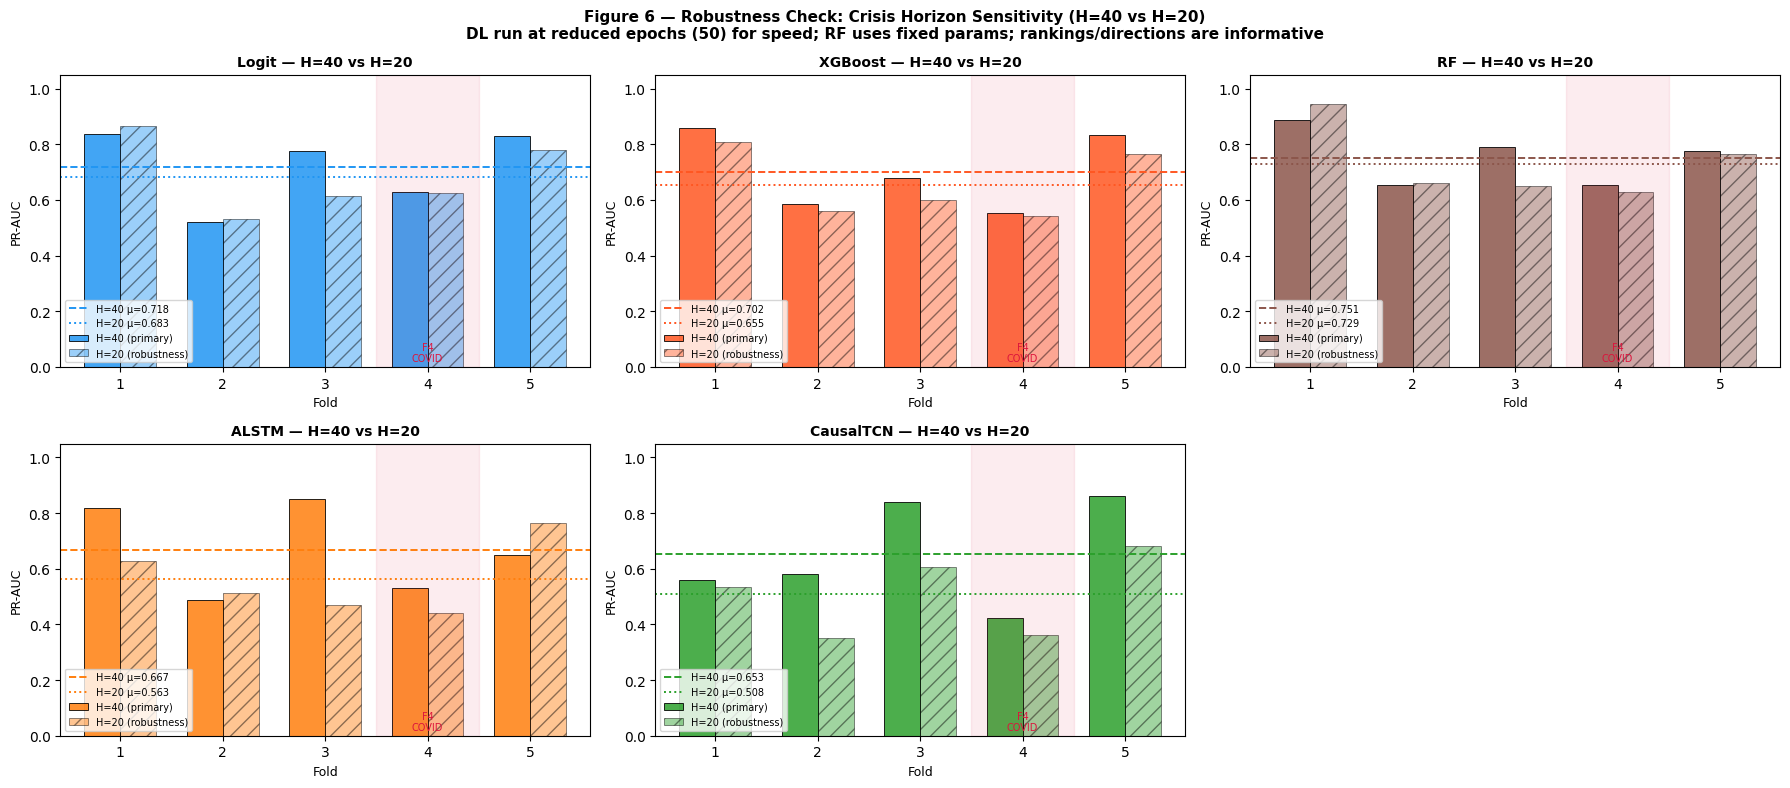

Saved → /content/drive/MyDrive/College Materials/Ajou University/thesis/ Early-Warning System for National Financial Instability/EWS model/outputs/fig_robustness_h20_h40.png
Saved → /content/drive/MyDrive/College Materials/Ajou University/thesis/ Early-Warning System for National Financial Instability/EWS model/outputs/robustness_h20_h40.csv


In [ ]:
import gc, warnings
warnings.filterwarnings('ignore')

HORIZON_20      = 20    # shorter horizon for robustness check
_RB_DL_EPOCHS   = 50   # reduced epochs for speed — tests ranking stability
_RB_DL_PATIENCE = 10

def _roll_fwd(arr, h):
    out = np.zeros_like(arr)
    for i in range(len(arr)):
        out[i] = arr[i:i+h].max() if i+h <= len(arr) else arr[i]
    return out

def run_cv_robustness(horizon: int, label: str = None,
                      include_dl: bool = True) -> dict:
    """
    5-fold walk-forward CV for all 5 models at a given target horizon.
    DL models run with reduced epochs (_RB_DL_EPOCHS=50) for speed;
    purpose is ranking/direction stability, not absolute performance.
    Returns dict: model_name -> list of per-fold PR_AUC values.
    """
    if label is None:
        label = f"H={horizon}"
    print(f"  Robustness CV — {label}  "
          f"({'Logit + XGBoost + RF + ALSTM + CausalTCN' if include_dl else 'Logit + XGBoost + RF'})")

    _tscv      = TimeSeriesSplit(n_splits=N_SPLITS, gap=horizon)
    _dummy     = np.zeros(N_seq)
    _models_rb = ['Logit', 'XGBoost', 'RF'] + (['ALSTM', 'CausalTCN'] if include_dl else [])
    pr_results = {m: [] for m in _models_rb}

    for fi, (tr_idx, te_idx) in enumerate(_tscv.split(_dummy), start=1):
        _tci_tr = pd.Series(tci_seq[tr_idx])
        _hmm_tr = pd.Series(hmm_seq[tr_idx])
        _fc     = int(_tci_tr.groupby(_hmm_tr).mean().idxmax())

        _raw   = (hmm_seq == _fc).astype(float)
        _y_seq = _roll_fwd(_raw, horizon)
        y_tr_r = _y_seq[tr_idx]
        y_te_r = _y_seq[te_idx]

        if y_tr_r.mean() < 0.01:
            for m in _models_rb:
                pr_results[m].append(np.nan)
            print(f"  Fold {fi}: SKIP (<1% positives)")
            continue

        vc         = int(len(tr_idx) * (1 - VAL_FRAC))
        X_tr_r     = X_seq[tr_idx[:vc]]
        y_tr_r_fit = y_tr_r[:vc]
        X_val_r    = X_seq[tr_idx[vc:]]
        y_val_r    = y_tr_r[vc:]
        X_te_r     = X_seq[te_idx]

        X2d_tr  = build_xgb_features(X_tr_r)
        X2d_val = build_xgb_features(X_val_r)
        X2d_te  = build_xgb_features(X_te_r)
        n_pos_f = y_tr_r_fit.sum()
        n_neg_f = len(y_tr_r_fit) - n_pos_f

        # ── Logit ────────────────────────────────────────────────────────────
        try:
            lg  = build_logit()
            lg.fit(X2d_tr, y_tr_r_fit.astype(int))
            _p  = lg.predict_proba(X2d_te)[:, 1]
            _pv = lg.predict_proba(X2d_val)[:, 1]
            _t  = max(find_optimal_threshold(y_val_r, _pv), THRESHOLD_FLOOR)
            pr_results['Logit'].append(evaluate_binary(y_te_r, _p, _t)['PR_AUC'])
        except Exception:
            pr_results['Logit'].append(np.nan)

        # ── XGBoost ──────────────────────────────────────────────────────────
        spw_r = min(n_neg_f / n_pos_f, MAX_CLASS_WEIGHT) if n_pos_f > 0 else 1.0
        xgb_r = xgb.XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=spw_r, eval_metric='logloss',
            use_label_encoder=False, early_stopping_rounds=20,
            random_state=42, verbosity=0,
        )
        xgb_r.fit(X2d_tr, y_tr_r_fit.astype(int),
                  eval_set=[(X2d_val, y_val_r.astype(int))], verbose=False)
        _pv_x = xgb_r.predict_proba(X2d_val)[:, 1]
        _p_x  = xgb_r.predict_proba(X2d_te)[:, 1]
        _tx   = max(find_optimal_threshold(y_val_r, _pv_x), THRESHOLD_FLOOR)
        pr_results['XGBoost'].append(evaluate_binary(y_te_r, _p_x, _tx)['PR_AUC'])

        # ── Random Forest (fixed params for speed) ───────────────────────────
        try:
            rf_r = RandomForestClassifier(
                n_estimators=300, max_depth=6, max_features='sqrt',
                class_weight='balanced_subsample', min_samples_leaf=5,
                random_state=42, n_jobs=-1,
            )
            rf_r.fit(X2d_tr, y_tr_r_fit.astype(int))
            _pv_rf = rf_r.predict_proba(X2d_val)[:, 1]
            _p_rf  = rf_r.predict_proba(X2d_te)[:, 1]
            _t_rf  = max(find_optimal_threshold(y_val_r, _pv_rf), THRESHOLD_FLOOR)
            pr_results['RF'].append(evaluate_binary(y_te_r, _p_rf, _t_rf)['PR_AUC'])
        except Exception:
            pr_results['RF'].append(np.nan)

        # ── DL (reduced epochs for speed) ────────────────────────────────────
        if include_dl:
            if n_pos_f > 0 and n_neg_f > 0:
                cw_r = {0: min(n_pos_f / (2 * n_neg_f), MAX_CLASS_WEIGHT),
                        1: min(n_neg_f / (2 * n_pos_f), MAX_CLASS_WEIGHT)}
            else:
                cw_r = {0: 1.0, 1: 1.0}

            _ls_eps = 0.05
            for _dl_name, _build_fn in [('ALSTM', build_alstm), ('CausalTCN', build_tcn)]:
                K.clear_session()
                _m  = _build_fn(n_features=X_tr_r.shape[2], lookback=LOOKBACK)
                _cb = [EarlyStopping(monitor='val_pr_auc', mode='max',
                                     patience=_RB_DL_PATIENCE, min_delta=0.005,
                                     restore_best_weights=True, verbose=0)]
                _y_smooth = np.clip(y_tr_r_fit * (1 - 2 * _ls_eps) + _ls_eps, 0., 1.)
                _m.fit(X_tr_r, _y_smooth,
                       validation_data=(X_val_r, y_val_r),
                       epochs=_RB_DL_EPOCHS, batch_size=BATCH_SIZE,
                       class_weight=cw_r, callbacks=_cb, verbose=0)
                _pv_dl  = _m.predict(X_val_r, verbose=0).ravel()
                _p_dl   = _m.predict(X_te_r,  verbose=0).ravel()
                _pv_cal = platt_scale(_pv_dl, y_val_r, _pv_dl)
                _p_cal  = platt_scale(_pv_dl, y_val_r, _p_dl)
                _t_dl   = max(find_optimal_threshold(y_val_r, _pv_cal), THRESHOLD_FLOOR)
                pr_results[_dl_name].append(evaluate_binary(y_te_r, _p_cal, _t_dl)['PR_AUC'])
                del _m; gc.collect()

        _fmt   = lambda m: f"{pr_results[m][-1]:.3f}" if not np.isnan(pr_results[m][-1]) else "NaN"
        _parts = [f"Logit={_fmt('Logit')}", f"XGB={_fmt('XGBoost')}", f"RF={_fmt('RF')}"]
        if include_dl:
            _parts += [f"ALSTM={_fmt('ALSTM')}", f"TCN={_fmt('CausalTCN')}"]
        print(f"  Fold {fi} | State={_fc} | " + "  ".join(_parts))

    print(f"\n  {'Model':<12} {'Mean PR-AUC':>12} {'Std':>8}")
    for mdl in _models_rb:
        vals = np.array(pr_results[mdl], dtype=float)
        print(f"  {mdl:<12} {np.nanmean(vals):>12.3f} {np.nanstd(vals):>8.3f}")
    return pr_results

# ── Run robustness CV at H=20 ─────────────────────────────────────────────────
pr_h20 = run_cv_robustness(HORIZON_20, label='H=20')

# ── Robustness comparison table (all 5 models) ────────────────────────────────
print("\n  Table — Robustness Check: H=40 (primary) vs H=20 (robustness)")
print(f"  |Delta| < 0.05 = robust  |  |Delta| < 0.10 = acceptable")
print(f"  {'Model':<12} {'H=40':>8} {'H=20':>8} {'Delta':>8}  Verdict")

robust_rows = []
_all_rb_models = [m for m in ['Logit', 'XGBoost', 'RF', 'ALSTM', 'CausalTCN'] if m in pr_h20]
for mdl in _all_rb_models:
    h40_vals = [fold_metrics[mdl][f].get('PR_AUC', np.nan) for f in range(N_SPLITS)]
    h40_mean = np.nanmean(h40_vals)
    h20_mean = np.nanmean(pr_h20[mdl])
    delta    = h20_mean - h40_mean
    if abs(delta) < 0.05:
        verdict = 'Robust ✓'
    elif abs(delta) < 0.10:
        verdict = 'Acceptable ⚠' if delta < 0 else 'Improved ↑'
    else:
        verdict = 'Sensitive ✗' if delta < 0 else 'Improved ↑'
    print(f"  {mdl:<12} {h40_mean:>8.3f} {h20_mean:>8.3f} {delta:>+8.3f}  {verdict}")
    robust_rows.append({'Model': mdl, 'H40': round(h40_mean, 3),
                        'H20': round(h20_mean, 3), 'Delta': round(delta, 3),
                        'Verdict': verdict})

robust_df = pd.DataFrame(robust_rows)

# ── Robustness plot: H=40 vs H=20 per fold, 2×3 grid (5 panels, 6th hidden) ──
_rb_colors = {
    'Logit':     '#2196F3',
    'XGBoost':   '#FF5722',
    'RF':        '#8c564b',
    'ALSTM':     '#ff7f0e',
    'CausalTCN': '#2ca02c',
}
folds_x = np.arange(1, N_SPLITS + 1)
w = 0.35

fig_rb, axes_rb = plt.subplots(2, 3, figsize=(18, 8), sharey=False)
axes_rb_flat = axes_rb.flatten()
axes_rb_flat[-1].set_visible(False)   # 6th panel unused

for ax_rb, mdl in zip(axes_rb_flat, _all_rb_models):
    h40 = [fold_metrics[mdl][f].get('PR_AUC', np.nan) for f in range(N_SPLITS)]
    h20 = pr_h20[mdl]
    ax_rb.bar(folds_x - w/2, h40, width=w, label='H=40 (primary)',
              color=_rb_colors[mdl], alpha=0.85, edgecolor='black', linewidth=0.7)
    ax_rb.bar(folds_x + w/2, h20, width=w, label='H=20 (robustness)',
              color=_rb_colors[mdl], alpha=0.45, edgecolor='black', linewidth=0.7, hatch='//')
    ax_rb.axhline(np.nanmean(h40), color=_rb_colors[mdl], ls='--', lw=1.4,
                  label=f"H=40 μ={np.nanmean(h40):.3f}")
    ax_rb.axhline(np.nanmean(h20), color=_rb_colors[mdl], ls=':', lw=1.4,
                  label=f"H=20 μ={np.nanmean(h20):.3f}")
    ax_rb.set_xlabel('Fold', fontsize=9)
    ax_rb.set_ylabel('PR-AUC', fontsize=9)
    ax_rb.set_title(f'{mdl} — H=40 vs H=20', fontweight='bold', fontsize=10)
    ax_rb.set_xticks(folds_x)
    ax_rb.set_ylim(0, 1.05)
    ax_rb.legend(fontsize=7, loc='lower left')
    ax_rb.axvspan(3.5, 4.5, alpha=0.08, color='crimson')
    ax_rb.text(4, 0.02, 'F4\nCOVID', ha='center', color='crimson', fontsize=7)

plt.suptitle('Figure 6 — Robustness Check: Crisis Horizon Sensitivity (H=40 vs H=20)\n'
             'DL run at reduced epochs (50) for speed; RF uses fixed params; '
             'rankings/directions are informative',
             fontsize=11, fontweight='bold')
plt.tight_layout()
rb_path = os.path.join(OUTPUT_DIR, 'fig_robustness_h20_h40.png')
plt.savefig(rb_path, dpi=160, bbox_inches='tight')
plt.show()
print(f"Saved → {rb_path}")

robust_df.to_csv(os.path.join(OUTPUT_DIR, 'robustness_h20_h40.csv'), index=False)
print(f"Saved → {os.path.join(OUTPUT_DIR, 'robustness_h20_h40.csv')}")

Defining feature groups from FEATURE_COLS: ['TCI', 'TO_JCI', 'TO_SP500', 'TO_SSE', 'TO_VIX', 'TO_WTI', 'TO_Gold', 'TO_USDIDR', 'FROM_JCI', 'FROM_SP500', 'FROM_SSE', 'FROM_VIX', 'FROM_WTI', 'FROM_Gold', 'FROM_USDIDR', 'NET_JCI', 'NET_SP500', 'NET_SSE', 'NET_VIX', 'NET_WTI', 'NET_Gold', 'NET_USDIDR']
  TCI_only       :  1 features  ['TCI']
  TO_FROM        : 14 features  ['TO_JCI', 'TO_SP500', 'TO_SSE', 'TO_VIX']...
  NET_only       :  7 features  ['NET_JCI', 'NET_SP500', 'NET_SSE', 'NET_VIX']...
  No_Pairwise    : 22 features  ['TCI', 'TO_JCI', 'TO_SP500', 'TO_SSE']...
  Full_22        : 22 features  ['TCI', 'TO_JCI', 'TO_SP500', 'TO_SSE']...

  Ablation CV — Logit, 5-fold walk-forward
  Fold 1: TCI_only=0.541  TO_FROM=0.840  NET_only=0.926  No_Pairwise=0.900  Full_22=0.900
  Fold 2: TCI_only=0.858  TO_FROM=0.522  NET_only=0.500  No_Pairwise=0.508  Full_22=0.508
  Fold 3: TCI_only=0.819  TO_FROM=0.778  NET_only=0.727  No_Pairwise=0.788  Full_22=0.788
  Fold 4: TCI_only=0.358  TO_FROM=0.

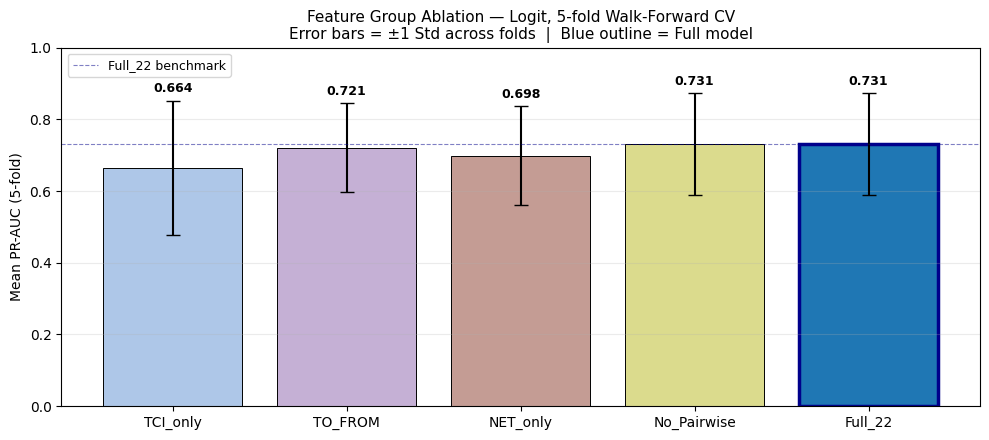


Saved → /content/drive/MyDrive/College Materials/Ajou University/thesis/ Early-Warning System for National Financial Instability/EWS model/outputs/fig_feature_ablation.png
Saved → /content/drive/MyDrive/College Materials/Ajou University/thesis/ Early-Warning System for National Financial Instability/EWS model/outputs/feature_ablation_results.csv


In [ ]:

print("Defining feature groups from FEATURE_COLS:", FEATURE_COLS)

_fc = FEATURE_COLS   # full list of 22 feature names

ABLATION_GROUPS = {
    'TCI_only'    : [f for f in _fc if f == 'TCI'],
    'TO_FROM'     : [f for f in _fc if f.startswith('TO_') or f.startswith('FROM_')],
    'NET_only'    : [f for f in _fc if f.startswith('NET_')],
    'No_Pairwise' : [f for f in _fc if not f.startswith('JCI_')],
    'Full_22'     : list(_fc),
}

for grp, cols in ABLATION_GROUPS.items():
    print(f"  {grp:<14} : {len(cols):>2} features  {cols[:4]}{'...' if len(cols)>4 else ''}")

print("\n  Ablation CV — Logit, 5-fold walk-forward")

_tscv_ab  = TimeSeriesSplit(n_splits=N_SPLITS, gap=HORIZON_40)
_dummy_ab = np.zeros(N_seq)

ablation_results = {grp: [] for grp in ABLATION_GROUPS}

for _fi, (_tr_ab, _te_ab) in enumerate(_tscv_ab.split(_dummy_ab), start=1):

    # Fold-level crisis state
    _tci_ab   = pd.Series(tci_seq[_tr_ab])
    _hmm_ab   = pd.Series(hmm_seq[_tr_ab])
    _fc_ab    = int(_tci_ab.groupby(_hmm_ab).mean().idxmax())

    _raw_ab   = (hmm_seq == _fc_ab).astype(float)
    _y_ab     = np.array([_raw_ab[i:i+HORIZON_40].max()
                          if i + HORIZON_40 <= len(_raw_ab) else _raw_ab[i]
                          for i in range(len(_raw_ab))])

    y_tr_ab   = _y_ab[_tr_ab]
    y_te_ab   = _y_ab[_te_ab]

    if y_tr_ab.mean() < 0.01:
        for grp in ABLATION_GROUPS:
            ablation_results[grp].append(np.nan)
        print(f"  Fold {_fi}: SKIP")
        continue

    # Validation cut
    _vc_ab    = int(len(_tr_ab) * (1 - VAL_FRAC))
    y_tr_fit_ = y_tr_ab[:_vc_ab]
    y_val_ab  = y_tr_ab[_vc_ab:]

    # Full X_seq is (N_seq, LOOKBACK, 22) — select feature columns by index
    _col_indices = {grp: [_fc.index(c) for c in cols]
                    for grp, cols in ABLATION_GROUPS.items()}

    fold_row = [_fi]
    for grp, feat_cols in ABLATION_GROUPS.items():
        _idx = _col_indices[grp]

        # Slice feature dimension
        X_tr_3d_ab  = X_seq[_tr_ab[:_vc_ab]][:, :, _idx]
        X_val_3d_ab = X_seq[_tr_ab[_vc_ab:]][:, :, _idx]
        X_te_3d_ab  = X_seq[_te_ab][:, :, _idx]

        X_tr_2d_ab  = build_xgb_features(X_tr_3d_ab)
        X_val_2d_ab = build_xgb_features(X_val_3d_ab)
        X_te_2d_ab  = build_xgb_features(X_te_3d_ab)

        try:
            _lg_ab = build_logit()
            _lg_ab.fit(X_tr_2d_ab, y_tr_fit_.astype(int))
            _pval_ab = _lg_ab.predict_proba(X_val_2d_ab)[:, 1]
            _pte_ab  = _lg_ab.predict_proba(X_te_2d_ab)[:, 1]
            _thr_ab  = max(find_optimal_threshold(y_val_ab, _pval_ab), THRESHOLD_FLOOR)
            _m_ab    = evaluate_binary(y_te_ab, _pte_ab, _thr_ab)
            ablation_results[grp].append(_m_ab['PR_AUC'])
        except Exception as _e:
            ablation_results[grp].append(np.nan)

    _pr_line = '  '.join([f"{g}={ablation_results[g][-1]:.3f}"
                           for g in ABLATION_GROUPS if not np.isnan(ablation_results[g][-1])])
    print(f"  Fold {_fi}: {_pr_line}")

print("\n  ABLATION SUMMARY — Mean PR-AUC ± Std across folds (Logit)")

ab_rows = []
for grp in ABLATION_GROUPS:
    vals    = np.array(ablation_results[grp], dtype=float)
    n_feat  = len(ABLATION_GROUPS[grp])
    n_stats = n_feat * 4
    ab_rows.append({
        'Feature Group': grp,
        'N Features'   : n_feat,
        'N Stats (input dim)': n_stats,
        'Mean PR-AUC'  : round(np.nanmean(vals), 4),
        'Std PR-AUC'   : round(np.nanstd(vals), 4),
    })

ab_df = pd.DataFrame(ab_rows).set_index('Feature Group')
print(ab_df.to_string())

# Incremental gain from Full vs TCI_only
_gain = ab_df.loc['Full_22','Mean PR-AUC'] - ab_df.loc['TCI_only','Mean PR-AUC']
print(f"\n  Incremental PR-AUC gain (Full_22 − TCI_only): {_gain:+.4f}")
print(f"  → {'Full network structure adds signal ✓' if _gain > 0.02 else 'TCI alone is near-sufficient for this dataset'}")

fig_ab, ax_ab = plt.subplots(figsize=(10, 4.5))

_groups  = list(ABLATION_GROUPS.keys())
_means   = [ab_df.loc[g, 'Mean PR-AUC'] for g in _groups]
_stds    = [ab_df.loc[g, 'Std PR-AUC']  for g in _groups]
_colors  = ['#aec7e8','#c5b0d5','#c49c94','#dbdb8d','#1f77b4']

_bars = ax_ab.bar(range(len(_groups)), _means, yerr=_stds,
                  color=_colors, edgecolor='black', linewidth=0.7,
                  capsize=5, error_kw={'elinewidth': 1.5, 'ecolor': 'black'})

# Full_22 highlight
_bars[-1].set_edgecolor('darkblue')
_bars[-1].set_linewidth(2.5)

for xi, (m, s) in enumerate(zip(_means, _stds)):
    ax_ab.text(xi, m + s + 0.015, f"{m:.3f}", ha='center', va='bottom',
               fontsize=9, fontweight='bold')

ax_ab.set_xticks(range(len(_groups)))
ax_ab.set_xticklabels(_groups, fontsize=10)
ax_ab.set_ylabel('Mean PR-AUC (5-fold)', fontsize=10)
ax_ab.set_title('Feature Group Ablation — Logit, 5-fold Walk-Forward CV\n'
                'Error bars = ±1 Std across folds  |  Blue outline = Full model',
                fontsize=11)
ax_ab.set_ylim(0, min(1.0, max(_means) + max(_stds) + 0.15))
ax_ab.grid(alpha=0.25, axis='y')
ax_ab.axhline(ab_df.loc['Full_22','Mean PR-AUC'], color='darkblue',
               lw=0.8, ls='--', alpha=0.5, label='Full_22 benchmark')
ax_ab.legend(fontsize=9)

plt.tight_layout()
ab_path = os.path.join(OUTPUT_DIR, 'fig_feature_ablation.png')
plt.savefig(ab_path, dpi=160, bbox_inches='tight')
plt.show()
print(f"\nSaved → {ab_path}")

ab_df.to_csv(os.path.join(OUTPUT_DIR, 'feature_ablation_results.csv'))
print(f"Saved → {os.path.join(OUTPUT_DIR, 'feature_ablation_results.csv')}")

In [19]:
# ── Build fold_df (per-fold metrics, all models) ─────────────────────────────
_metrics_list = ['PR_AUC', 'ROC_AUC', 'F1', 'Recall', 'Precision', 'Skill', 'Threshold']
fold_df_rows = []
for fi in range(N_SPLITS):
    row = {'Fold': fi + 1}
    for m in MODEL_ORDER:
        for met in _metrics_list:
            row[f'{m}_{met}'] = round(fold_metrics[m][fi].get(met, np.nan), 4)
    fold_df_rows.append(row)
fold_df = pd.DataFrame(fold_df_rows).set_index('Fold')

# ── Build summary_df (mean ± std across folds, all models) ───────────────────
summary_rows = []
for m in MODEL_ORDER:
    row = {'Model': m}
    for met in _metrics_list:
        vals = np.array([fold_metrics[m][fi].get(met, np.nan) for fi in range(N_SPLITS)], dtype=float)
        row[f'{met}_mean'] = round(np.nanmean(vals), 4)
        row[f'{met}_std']  = round(np.nanstd(vals),  4)
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows).set_index('Model')

print("fold_df shape   :", fold_df.shape)
print("summary_df shape:", summary_df.shape)
print()
print(summary_df[['PR_AUC_mean', 'PR_AUC_std', 'ROC_AUC_mean', 'F1_mean', 'Recall_mean', 'Skill_mean']].to_string())

# (a) Per-fold detail CSV
fold_csv_path = os.path.join(OUTPUT_DIR, 'phase3_fold_results.csv')
fold_df.to_csv(fold_csv_path)
print(f"\nSaved: {fold_csv_path}")

# (b) Summary table CSV
summary_csv_path = os.path.join(OUTPUT_DIR, 'phase3_model_summary.csv')
summary_df.to_csv(summary_csv_path)
print(f"Saved: {summary_csv_path}")

# (c) DM test results CSV
if 'dm_df' in dir() and dm_df is not None:
    dm_csv_path = os.path.join(OUTPUT_DIR, 'phase3_dm_test.csv')
    dm_df.to_csv(dm_csv_path, index=False)
    print(f"Saved: {dm_csv_path}")

# (d) Bootstrap CI CSV
if 'boot_ci' in dir():
    boot_rows_exp = [
        {'Model': m, 'PR_AUC': v[0], 'CI_lo_95': v[1], 'CI_hi_95': v[2]}
        for m, v in boot_ci.items()
    ]
    boot_csv_path = os.path.join(OUTPUT_DIR, 'phase3_bootstrap_ci.csv')
    pd.DataFrame(boot_rows_exp).to_csv(boot_csv_path, index=False)
    print(f"Saved: {boot_csv_path}")

# (e) SHAP importance CSVs (XGBoost reference; DL CSVs saved inside SHAP cell)
if 'imp_xgb' in dir() and imp_xgb is not None:
    imp_xgb.to_csv(os.path.join(OUTPUT_DIR, 'phase3_shap_xgb.csv'), index=False)
    print(f"Saved SHAP importance CSV (XGBoost reference).")

# (f) Aligned labels export
labels_export = df[['hmm_state', 'Target_40d', 'Target_60d']].copy()
labels_export['crisis_state'] = CRISIS_STATE
labels_csv_path = os.path.join(OUTPUT_DIR, 'phase3_target_labels.csv')
labels_export.to_csv(labels_csv_path)
print(f"Saved: {labels_csv_path}")

# (g) List all output files
print(f"\nFiles in {OUTPUT_DIR}:")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fsize = os.path.getsize(os.path.join(OUTPUT_DIR, fname))
    print(f"  {fname:<55} ({fsize:,} bytes)")


fold_df shape   : (5, 35)
summary_df shape: (5, 14)

           PR_AUC_mean  PR_AUC_std  ROC_AUC_mean  F1_mean  Recall_mean  Skill_mean
Model                                                                             
Logit           0.7185      0.1243        0.7223   0.7027       0.8170      0.3204
XGBoost         0.7021      0.1237        0.6915   0.6305       0.7424      0.2459
RF              0.7515      0.0889        0.7263   0.4896       0.5987      0.1021
ALSTM           0.6672      0.1462        0.6595   0.7063       0.9510      0.4545
CausalTCN       0.6532      0.1697        0.6741   0.6362       0.8026      0.3060

Saved: /content/drive/MyDrive/College Materials/Ajou University/thesis/ Early-Warning System for National Financial Instability/EWS model/outputs/phase3_fold_results.csv
Saved: /content/drive/MyDrive/College Materials/Ajou University/thesis/ Early-Warning System for National Financial Instability/EWS model/outputs/phase3_model_summary.csv
Saved: /content/drive/My

## 5. Discussion & EWS Design Recommendations